# DESARROLLO DE MODELOS DE MACHINE LEARNING

Desarrollado Por: 
* Daniel Arturo Martinez Morales 
* Luis Miguel Ortega Cañate

A continuacion se presenta el desarrollo de la fase de entrenamiento  y test de los modelos  de machine learning  para el desarrollo de un Sistema Clasificador de Resultados de Análisis de Aceite Usado en Motores de Maquinaria Pesada.

**Nota:** Para el desarrollo de esta fase se tiene en cuenta ls fase de exploración de los datos desarrolado previamente en el Noteboock llamado "Exploracion de datos".

## Balanceo de Muestras 

Durante la fase de exploración de datos se identificó un desbalance significativo
en la variable objetivo `Assigned Condition Rating`, donde la clase Normal concentra
la gran mayoría de las observaciones, mientras que las clases Advertencia y Crítico
representan una proporción considerablemente menor del total de muestras.

Este desbalance es inherente al dominio del problema: en operación normal, la mayor
parte de los componentes de una flota minera se encuentran en condición saludable,
y los eventos de advertencia o falla crítica son relativamente poco frecuentes.

Sin embargo, este desbalance introduce
los siguientes riesgos si no es tratado:

- El modelo tiende a clasificar la mayoría de muestras como Normal para maximizar
  el accuracy global, ignorando las clases minoritarias.
- Se genera un sesgo hacia la clase mayoritaria, reduciendo drásticamente el
  desempeño  para las clases Advertencia y Crítico, que son precisamente las
  de mayor valor operativo para el negocio.
- Las métricas globales como el Accuracy resultan engañosas, ocultando el
  bajo desempeño real del modelo sobre las condiciones anómalas.

Detectar una condición Crítica que el modelo clasifica como Normal representa un Falso Negativo de alto costo operativo, asociado directamente a las pérdidas de ~500 kUSD/año documentadas en el planteamiento del problema.


In [5]:
import pandas as pd
data_cleaned = pd.read_excel("../Exploración/Analisis De Aceite Flotas Mineras.xlsx")

In [6]:
print("=== Distribución original de clases ===")
print(data_cleaned['Assigned Condition Rating'].value_counts())
print(data_cleaned['Assigned Condition Rating'].value_counts(normalize=True)
      .mul(100).round(2).astype(str) + ' %')

=== Distribución original de clases ===
Assigned Condition Rating
Normal      3607
Warning      522
Critical     154
Name: count, dtype: int64
Assigned Condition Rating
Normal      84.22 %
Warning     12.19 %
Critical      3.6 %
Name: proportion, dtype: object


In [12]:
import pandas as pd
import numpy as np


# CALIFICACIÓN SACODE - Generación de Límites Condenatorios (Metodología Noria)


## Definición de Predictores según cada Categoría
Salud = data_cleaned[['Boro (ppm)', 'Calcio (ppm)', 'Cinc (ppm)', 'Fosforado (ppm)',
                       'Magnesio (ppm)', 'Molibdeno (ppm)', 'Nitración JOAP (Abs/cm)',
                       'Oxidación JOAP (Abs/cm)', 'Sulfatación JOAP (Abs/cm)', 'Sodio (ppm)']]

Desgaste = data_cleaned[['Aluminio (ppm)', 'Cobre (ppm)', 'Cromo (ppm)', 'Estaño (ppm)',
                          'Hierro (ppm)', 'Plomo (ppm)',
                          'Oxidación JOAP (Abs/cm)']]

Contaminacion = data_cleaned[['Agua (%)', 'Dilución por combustible (%)',
                               'Hollín JOAP (Abs/cm)', 'Silicio (ppm)',
                               'Sodio (ppm)', 'Aluminio (ppm)']]



def calcular_limites(df: pd.DataFrame, 
                     factor_warning: float = 2.0, 
                     factor_critico: float = 3.0) -> pd.DataFrame:

    stats = pd.DataFrame({
        'media'           : df.mean(),
        'sigma'           : df.std(),
        'lim_warn_sup'    : df.mean() + factor_warning * df.std(),
        'lim_warn_inf'    : df.mean() - factor_warning * df.std(),
        'lim_critico_sup' : df.mean() + factor_critico * df.std(),
        'lim_critico_inf' : df.mean() - factor_critico * df.std(),
    })

    stats['lim_warn_inf']    = stats['lim_warn_inf'].clip(lower=0)
    stats['lim_critico_inf'] = stats['lim_critico_inf'].clip(lower=0)

    return stats



def clasificar_predictor(valor: float, 
                         lim_warn_sup: float, 
                         lim_critico_sup: float) -> str:

    if valor <= lim_warn_sup:
        return 'Normal'
    elif valor <= lim_critico_sup:
        return 'Advertencia'
    else:
        return 'Crítico'



# Función: Calificación SACODE por categoría (criterio de peor caso)


def calificar_categoria(df: pd.DataFrame, limites: pd.DataFrame) -> pd.Series:

    orden_severidad = {'Normal': 0, 'Advertencia': 1, 'Crítico': 2}
    inv_orden       = {v: k for k, v in orden_severidad.items()}

    calificaciones = pd.DataFrame(index=df.index)

    for col in df.columns:
        lim_w = limites.loc[col, 'lim_warn_sup']
        lim_c = limites.loc[col, 'lim_critico_sup']
        calificaciones[col] = df[col].apply(
            lambda x: clasificar_predictor(x, lim_w, lim_c)
        )

    # Peor caso: máximo nivel de severidad entre todos los predictores por fila
    peor_caso = calificaciones.map(lambda x: orden_severidad[x]).max(axis=1)

    return peor_caso.map(inv_orden)



# Cálculo de Límites por Categoría


limites_salud        = calcular_limites(Salud)
limites_desgaste     = calcular_limites(Desgaste)
limites_contaminacion = calcular_limites(Contaminacion)

print("=== Límites Salud ===")
print(limites_salud.round(3), "\n")

print("=== Límites Desgaste ===")
print(limites_desgaste.round(3), "\n")

print("=== Límites Contaminación ===")
print(limites_contaminacion.round(3), "\n")

# Asignación de Calificación SACODE al dataset


data_cleaned['SACODE_Salud']         = calificar_categoria(Salud,         limites_salud)
data_cleaned['SACODE_Desgaste']      = calificar_categoria(Desgaste,      limites_desgaste)
data_cleaned['SACODE_Contaminacion'] = calificar_categoria(Contaminacion, limites_contaminacion)

=== Límites Salud ===
                              media    sigma  lim_warn_sup  lim_warn_inf  \
Boro (ppm)                   57.419   39.573       136.565         0.000   
Calcio (ppm)               2045.069  690.602      3426.273       663.865   
Cinc (ppm)                 1351.095  149.697      1650.489      1051.702   
Fosforado (ppm)            1179.651   78.502      1336.655      1022.647   
Magnesio (ppm)              241.588  142.551       526.691         0.000   
Molibdeno (ppm)              53.587   14.047        81.680        25.494   
Nitración JOAP (Abs/cm)       5.791    1.364         8.518         3.063   
Oxidación JOAP (Abs/cm)      13.620    2.617        18.855         8.385   
Sulfatación JOAP (Abs/cm)    18.457    2.613        23.683        13.231   
Sodio (ppm)                   5.874   47.363       100.600         0.000   

                           lim_critico_sup  lim_critico_inf  
Boro (ppm)                         176.139            0.000  
Calcio (ppm)     

In [13]:

# Limite Warning sodio
limites_salud.loc['Sodio (ppm)', 'lim_warn_sup'] = 40
# Limite Critico sodio
limites_salud.loc['Sodio (ppm)', 'lim_critico_sup'] = 100
# Limite Warning  Oxidacion JOAP
limites_salud.loc['Oxidación JOAP (Abs/cm)', 'lim_warn_sup'] = 19
# Limite Critico  Oxidacion JOAP
limites_salud.loc['Oxidación JOAP (Abs/cm)', 'lim_critico_sup'] = 21
# Limite Warning Cobre
limites_desgaste.loc['Cobre (ppm)', 'lim_warn_sup'] = 6
# Limite Critico Cobre
limites_desgaste.loc['Cobre (ppm)', 'lim_critico_sup'] = 8
#Limite Warning Plomo
limites_desgaste.loc['Plomo (ppm)', 'lim_warn_sup'] = 4
#Limite Critico Plomo
limites_desgaste.loc['Plomo (ppm)', 'lim_critico_sup'] = 6

In [15]:
data_cleaned['SACODE_Salud']         = calificar_categoria(Salud,         limites_salud)
data_cleaned['SACODE_Desgaste']      = calificar_categoria(Desgaste,      limites_desgaste)
data_cleaned['SACODE_Contaminacion'] = calificar_categoria(Contaminacion, limites_contaminacion)

In [16]:
data_cleaned['SACODE_General'] = data_cleaned[['SACODE_Salud', 'SACODE_Desgaste', 'SACODE_Contaminacion']].apply(
    lambda x: 'Crítico' if 'Crítico' in x.values else ('Advertencia' if 'Advertencia' in x.values else 'Normal'),
    axis=1
)

### Estrategia de Balanceo

Para mitigar el desbalance se aplica la técnica SMOTE, que genera muestras sintéticas
para las clases minoritarias interpolando entre observaciones reales del espacio
de características, en lugar de simplemente duplicar registros existentes.

In [10]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split


# Variables predictoras y variable objetivo
X = data_cleaned.drop(columns=['Assigned Condition Rating',
                                'ACR_Homologado',
                                'Assigned Condition Rating',
                                'Fault Effect',
                                'SACODE_Salud',
                                'SACODE_Desgaste',
                                'SACODE_Contaminacion',
                                'SACODE_General','Flota','Rule Based Rating'])

y = data_cleaned['Fault Effect']


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y       
)

print("=== Distribución antes de SMOTE (Train) ===")
print(y_train.value_counts())

# Aplicación de SMOTE exclusivamente sobre el conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\n=== Distribución después de SMOTE (Train) ===")
print(pd.Series(y_train_bal).value_counts())
print("\n=== Conjunto de prueba (sin modificar) ===")
print(y_test.value_counts())

=== Distribución antes de SMOTE (Train) ===
Assigned Condition Rating
Normal      2885
Warning      418
Critical     123
Name: count, dtype: int64

=== Distribución después de SMOTE (Train) ===
Assigned Condition Rating
Normal      2885
Warning     2885
Critical    2885
Name: count, dtype: int64

=== Conjunto de prueba (sin modificar) ===
Assigned Condition Rating
Normal      722
Warning     104
Critical     31
Name: count, dtype: int64


c:\Users\Daniel Martinez\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Daniel Martinez\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Daniel Martinez\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Daniel Martinez\AppData\Local\Pro

## Parte V: Calificación SACODE (Salud - Contaminación - Desgaste)

* En esta etapa se incluyen nuevas features al dataset previamente depurado.
* Se agregan 3 nuevas variables al dataframe: **Salud**, **Contaminación** y **Desgaste**.
* Cada una de estas variables puede tomar 3 estados posibles: **Normal**, **Advertencia** y **Crítico**.
* La calificación se construye mediante la generación de **límites condenatorios** para los predictores
  asociados a cada categoría SACODE, siguiendo la metodología de Noria.
* Los límites se calculan a partir de la media y la desviación estándar de cada predictor,
  definidos de la siguiente manera:

  * **Límite Warning:**
    $$L_{warning} = \bar{x} \pm 2\sigma$$

  * **Límite Crítico:**
    $$L_{critico} = \bar{x} \pm 3\sigma$$

* La lógica de clasificación por predictor opera de la siguiente forma:
  * Si el valor observado se encuentra dentro del **Límite Warning** → estado **Normal**
  * Si el valor observado supera el **Límite Warning** pero no el **Límite Crítico** → estado **Advertencia**
  * Si el valor observado supera el **Límite Crítico** → estado **Crítico**

* La calificación final de cada categoría SACODE (Salud, Contaminación, Desgaste)
  corresponde al estado más severo registrado entre todos sus predictores asociados
  (criterio de peor caso).

In [35]:
Salud_train = X_train_bal[['Boro (ppm)', 'Calcio (ppm)', 'Cinc (ppm)', 'Fosforado (ppm)',
                       'Magnesio (ppm)', 'Molibdeno (ppm)', 'Nitración JOAP (Abs/cm)',
                       'Oxidación JOAP (Abs/cm)', 'Sulfatación JOAP (Abs/cm)', 'Sodio (ppm)']]

Desgaste_train = X_train_bal[['Aluminio (ppm)', 'Cobre (ppm)', 'Cromo (ppm)', 'Estaño (ppm)',
                          'Hierro (ppm)', 'Plomo (ppm)',
                          'Oxidación JOAP (Abs/cm)']]

Contaminacion_train = X_train_bal[['Agua (%)', 'Dilución por combustible (%)',
                               'Hollín JOAP (Abs/cm)', 'Silicio (ppm)',
                               'Sodio (ppm)', 'Aluminio (ppm)']]


In [36]:
X_train_bal['SACODE_Salud']         = calificar_categoria(Salud_train,         limites_salud)
X_train_bal['SACODE_Desgaste']      = calificar_categoria(Desgaste_train,      limites_desgaste)
X_train_bal['SACODE_Contaminacion'] = calificar_categoria(Contaminacion_train, limites_contaminacion)
X_train_bal['SACODE_General'] = X_train_bal[['SACODE_Salud', 'SACODE_Desgaste', 'SACODE_Contaminacion']].apply(
    lambda x: 'Crítico' if 'Crítico' in x.values else ('Advertencia' if 'Advertencia' in x.values else 'Normal'),
    axis=1
)

In [37]:
Salud_test = X_test[['Boro (ppm)', 'Calcio (ppm)', 'Cinc (ppm)', 'Fosforado (ppm)',
                       'Magnesio (ppm)', 'Molibdeno (ppm)', 'Nitración JOAP (Abs/cm)',
                       'Oxidación JOAP (Abs/cm)', 'Sulfatación JOAP (Abs/cm)', 'Sodio (ppm)']]

Desgaste_test = X_test[['Aluminio (ppm)', 'Cobre (ppm)', 'Cromo (ppm)', 'Estaño (ppm)',
                          'Hierro (ppm)', 'Plomo (ppm)',
                          'Oxidación JOAP (Abs/cm)']]

Contaminacion_test = X_test[['Agua (%)', 'Dilución por combustible (%)',
                               'Hollín JOAP (Abs/cm)', 'Silicio (ppm)',
                               'Sodio (ppm)', 'Aluminio (ppm)']]

In [38]:
X_test['SACODE_Salud']         = calificar_categoria(Salud_test,         limites_salud)
X_test['SACODE_Desgaste']      = calificar_categoria(Desgaste_test,      limites_desgaste)
X_test['SACODE_Contaminacion'] = calificar_categoria(Contaminacion_test, limites_contaminacion)
X_test['SACODE_General'] = X_test[['SACODE_Salud', 'SACODE_Desgaste', 'SACODE_Contaminacion']].apply(
    lambda x: 'Crítico' if 'Crítico' in x.values else ('Advertencia' if 'Advertencia' in x.values else 'Normal'),
    axis=1
)

In [39]:
X_train_bal

,Unnamed: 0,Boro (ppm),Calcio (ppm),Cinc (ppm),Fosforado (ppm),Magnesio (ppm),Molibdeno (ppm),Agua (%),Dilución por combustible (%),Hollín JOAP (Abs/cm),...,Aluminio (ppm),Cobre (ppm),Cromo (ppm),Estaño (ppm),Hierro (ppm),Plomo (ppm),SACODE_Salud,SACODE_Desgaste,SACODE_Contaminacion,SACODE_General
0,1466,57.390000,1884.000000,1257.000000,1196.000000,347.190000,59.400000,0.0,0.000000,13.000000,...,1.070000,1.230000,0.210000,1.070000,4.730000,2.080000,Normal,Normal,Normal,Normal
1,2501,43.640000,3440.728417,1359.057585,1045.309902,21.980000,37.280000,0.0,0.000000,4.000000,...,1.790000,0.340000,0.280000,0.000000,3.500000,0.000000,Advertencia,Normal,Normal,Advertencia
2,1447,46.010000,1978.000000,1575.000000,1228.000000,350.510000,70.480000,0.0,0.000000,28.900000,...,0.910000,4.310000,0.340000,0.000000,14.510000,20.440000,Normal,Crítico,Crítico,Crítico
3,504,114.020000,1610.000000,1362.436568,1218.454965,313.700000,63.160000,0.0,0.000000,2.000000,...,0.390000,0.230000,0.200000,0.000000,2.710000,0.000000,Normal,Normal,Normal,Normal
4,2324,44.390000,3210.000000,1293.061681,1080.786360,21.030000,33.730000,0.0,0.180000,5.000000,...,1.240000,0.450000,0.400000,0.000000,3.630000,0.460000,Normal,Normal,Normal,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22979,720,79.984138,1481.279748,1317.896456,1089.149878,256.282071,54.338484,0.0,0.409463,10.560548,...,0.226318,1.405855,0.030762,0.000000,2.780962,0.000000,Normal,Normal,Normal,Normal
22980,685,63.262807,1697.297336,1351.745657,1244.268297,316.470898,59.202862,0.0,0.494863,18.371576,...,0.272584,1.440179,0.360453,0.072116,5.918872,0.041874,Normal,Normal,Normal,Normal
22981,619,84.859816,1711.685859,1418.636309,1275.392232,324.683515,66.596097,0.0,0.192041,10.801015,...,0.958772,0.683531,0.393429,0.000000,3.859153,0.000000,Normal,Normal,Normal,Normal
22982,685,67.541239,1632.070752,1338.664467,1196.096622,294.653236,57.474962,0.0,0.528387,17.154831,...,0.129935,1.584710,0.273548,0.000000,5.316577,0.000000,Normal,Normal,Normal,Normal


### Desarrollo de Modelos de Aprendizaje 

* Una vez balencados la muestras de la base de datos suministrados por el cliente se proccede a generar los Pipeline de entrenamiento y de test de los algoritmos candidatos a ser utilizados en este proyecto los cuales son: 

1. Modelo de Ensaamble de Random Forest
2. Modelo de Ensamble de Gradient Boosting
3. Modelo de  Regresion Logistica 
4. Modelo de Support Vector Machine (SVM)
5. Modelos de Redes Neuronales  Multi-Layer Perceptron


A continuación, se muestra el pipeline desarrollado para  los modelos escogidos.

VALIDACIÓN CRUZADA — 5-Fold Estratificado (Train Balanceado)

  ▶ Entrenando CV: Logistic Regression...
    F1 Weighted : 0.8006 (±0.0055)
    Recall      : 0.8007
    Accuracy    : 0.8007

  ▶ Entrenando CV: Random Forest...
    F1 Weighted : 0.9864 (±0.0008)
    Recall      : 0.9865
    Accuracy    : 0.9865

  ▶ Entrenando CV: XGBoost...
    F1 Weighted : 0.9867 (±0.0015)
    Recall      : 0.9868
    Accuracy    : 0.9868

  ▶ Entrenando CV: LightGBM...
    F1 Weighted : 0.9899 (±0.0015)
    Recall      : 0.9900
    Accuracy    : 0.9900

  ▶ Entrenando CV: SVM...
    F1 Weighted : 0.9708 (±0.0018)
    Recall      : 0.9716
    Accuracy    : 0.9716

  ▶ Entrenando CV: MLP...
    F1 Weighted : 0.9811 (±0.0028)
    Recall      : 0.9814
    Accuracy    : 0.9814

=== Resumen Validación Cruzada ===
                     F1 Weighted (CV)  F1 Weighted Std  Recall Weighted (CV)  \
LightGBM                       0.9899           0.0015                0.9900   
XGBoost                        0.986

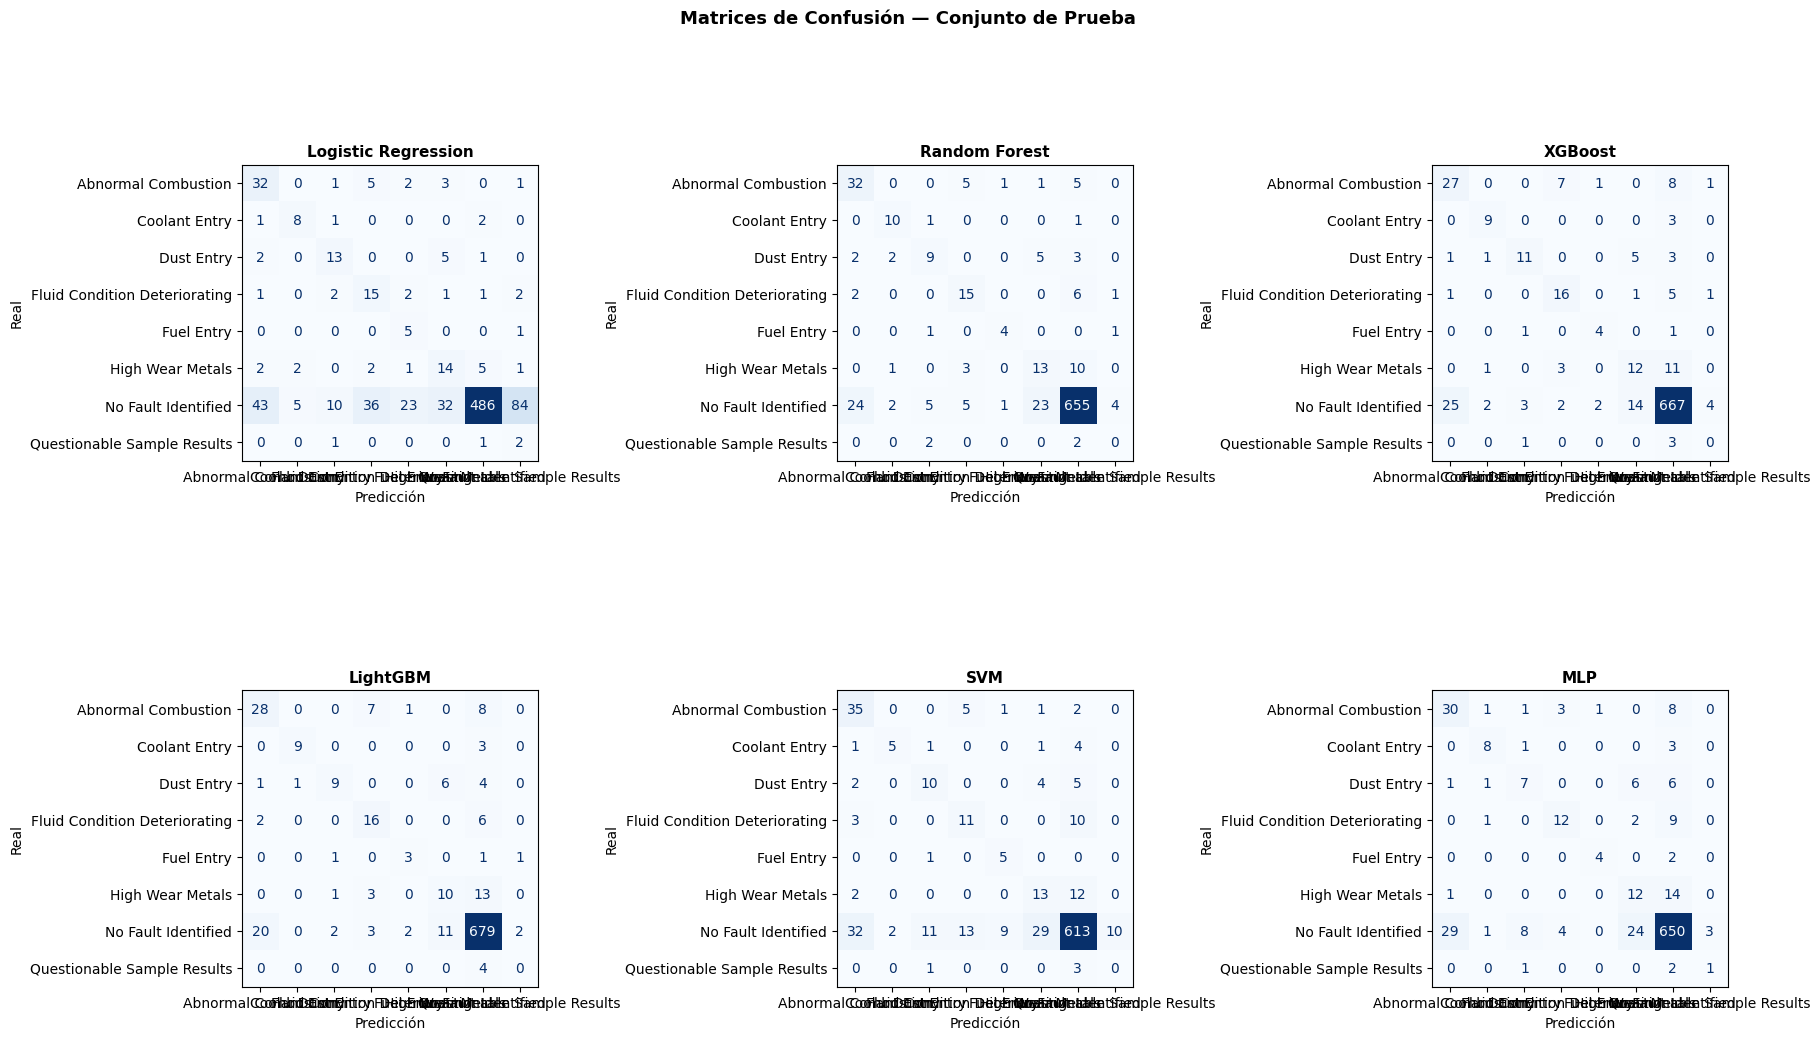

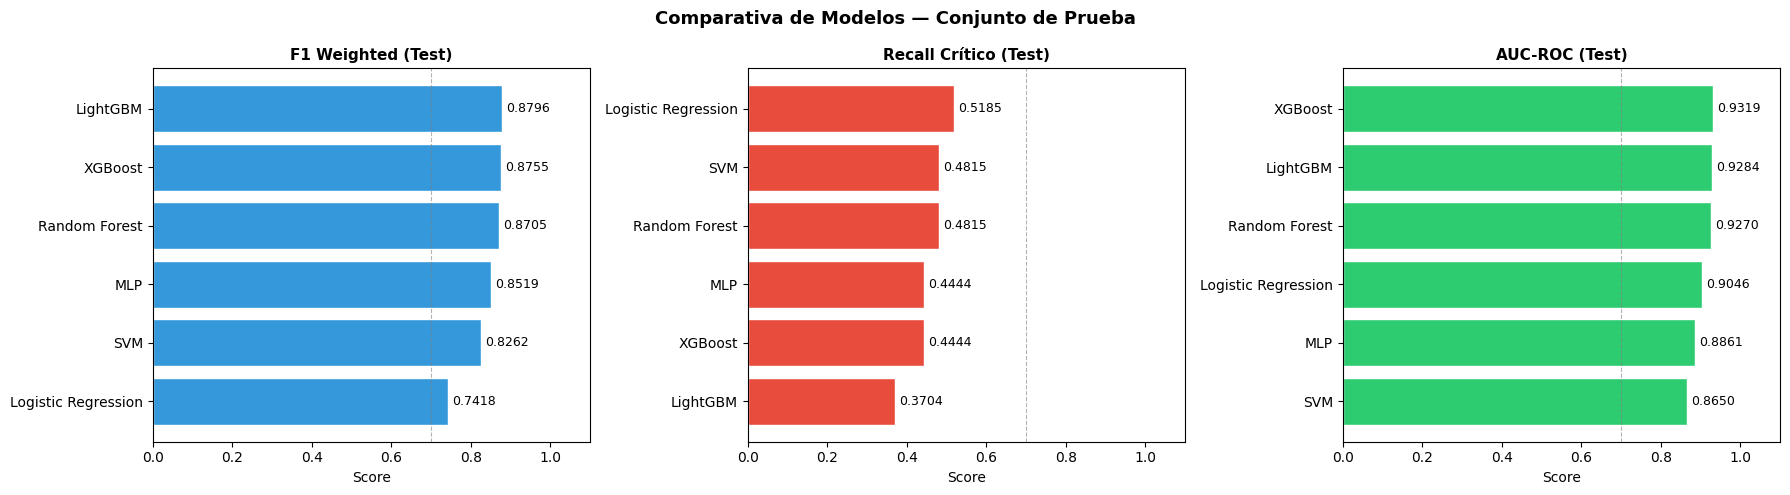

In [50]:
# ==============================================================================
# PIPELINE DE ENTRENAMIENTO — OilSense ML (VERSIÓN FINAL SIN SMOTE)
# ==============================================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.svm              import SVC
from sklearn.neural_network   import MLPClassifier
from sklearn.preprocessing    import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline         import Pipeline
from sklearn.compose          import ColumnTransformer
from sklearn.model_selection  import StratifiedKFold, cross_validate
from sklearn.metrics          import (classification_report,
                                      confusion_matrix,
                                      ConfusionMatrixDisplay,
                                      f1_score, recall_score,
                                      roc_auc_score)

from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier

os.environ['LOKY_MAX_CPU_COUNT'] = '4'
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. COLUMNAS
# ==============================================================================

COLS_DROP = ['Unnamed: 0']

COLS_NUMERICAS = [
    'Boro (ppm)', 'Calcio (ppm)', 'Cinc (ppm)', 'Fosforado (ppm)',
    'Magnesio (ppm)', 'Molibdeno (ppm)', 'Agua (%)',
    'Dilución por combustible (%)', 'Hollín JOAP (Abs/cm)',
    'Nitración JOAP (Abs/cm)', 'Oxidación JOAP (Abs/cm)',
    'Silicio (ppm)', 'Sodio (ppm)', 'Sulfatación JOAP (Abs/cm)',
    'Viscosidad @ 100°C (cSt)', 'Aluminio (ppm)', 'Cobre (ppm)',
    'Cromo (ppm)', 'Estaño (ppm)', 'Hierro (ppm)', 'Plomo (ppm)'
]

COLS_SACODE = [
    'SACODE_Salud',
    'SACODE_Desgaste',
    'SACODE_Contaminacion',
    'SACODE_General'
]

ORDEN_SEVERIDAD = [['Normal', 'Advertencia', 'Crítico']] * len(COLS_SACODE)

# ==============================================================================
# 2. LIMPIEZA DE FEATURES
# ==============================================================================

X_train_bal_clean = X_train_bal.drop(columns=[c for c in COLS_DROP if c in X_train_bal.columns])
X_test_clean      = X_test.drop(columns=[c for c in COLS_DROP if c in X_test.columns])

# ==============================================================================
# 3. LABEL ENCODER (CONSISTENTE)
# ==============================================================================

label_encoder = LabelEncoder()

all_labels = pd.concat([y_train_bal, y_test]).unique()
label_encoder.fit(all_labels)

y_train_enc = label_encoder.transform(y_train_bal)
y_test_enc  = label_encoder.transform(y_test)

CLASES   = label_encoder.classes_
N_CLASES = len(CLASES)

# ==============================================================================
# 4. PREPROCESADORES
# ==============================================================================

preprocessor_scaled = ColumnTransformer([
    ('num', StandardScaler(), COLS_NUMERICAS),
    ('cat', OrdinalEncoder(
        categories=ORDEN_SEVERIDAD,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ), COLS_SACODE)
])

preprocessor_passthrough = ColumnTransformer([
    ('num', 'passthrough', COLS_NUMERICAS),
    ('cat', OrdinalEncoder(
        categories=ORDEN_SEVERIDAD,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ), COLS_SACODE)
])

# ==============================================================================
# 5. MODELOS
# ==============================================================================

modelos = {

    'Logistic Regression': Pipeline([
        ('prep', preprocessor_scaled),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]),

    'Random Forest': Pipeline([
        ('prep', preprocessor_passthrough),
        ('clf', RandomForestClassifier(
            n_estimators=400,
            max_depth=20,
            class_weight='balanced',
            n_jobs=-1,
            random_state=42
        ))
    ]),

    'XGBoost': Pipeline([
        ('prep', preprocessor_passthrough),
        ('clf', XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='multi:softprob',
            num_class=N_CLASES,
            eval_metric='mlogloss',
            n_jobs=-1,
            random_state=42
        ))
    ]),

    'LightGBM': Pipeline([
        ('prep', preprocessor_passthrough),
        ('clf', LGBMClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            class_weight='balanced',
            n_jobs=-1,
            random_state=42,
            verbose=-1
        ))
    ]),

    'SVM': Pipeline([
        ('prep', preprocessor_scaled),
        ('clf', SVC(
            kernel='rbf',
            C=10,
            class_weight='balanced',
            probability=True
        ))
    ]),

    'MLP': Pipeline([
        ('prep', preprocessor_scaled),
        ('clf', MLPClassifier(
            hidden_layer_sizes=(128, 64),
            max_iter=500,
            early_stopping=True,
            random_state=42
        ))
    ])
}

# ==============================================================================
# 5. VALIDACIÓN CRUZADA — 5-Fold Estratificado
# ==============================================================================

print("=" * 65)
print("VALIDACIÓN CRUZADA — 5-Fold Estratificado (Train Balanceado)")
print("=" * 65)

CV           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
METRICAS_CV  = ['f1_weighted', 'recall_weighted', 'accuracy']
resultados_cv = {}

for nombre, pipeline in modelos.items():
    print(f"\n  ▶ Entrenando CV: {nombre}...")
    cv_result = cross_validate(
        estimator          = pipeline,
        X                  = X_train_bal_clean,
        y                  = y_train_enc,
        cv                 = CV,
        scoring            = METRICAS_CV,
        n_jobs             = -1,
        return_train_score = False,
        error_score        = 'raise'
    )
    resultados_cv[nombre] = {
        'F1 Weighted (CV)'    : cv_result['test_f1_weighted'].mean(),
        'F1 Weighted Std'     : cv_result['test_f1_weighted'].std(),
        'Recall Weighted (CV)': cv_result['test_recall_weighted'].mean(),
        'Accuracy (CV)'       : cv_result['test_accuracy'].mean(),
    }
    print(f"    F1 Weighted : {resultados_cv[nombre]['F1 Weighted (CV)']:.4f} "
          f"(±{resultados_cv[nombre]['F1 Weighted Std']:.4f})")
    print(f"    Recall      : {resultados_cv[nombre]['Recall Weighted (CV)']:.4f}")
    print(f"    Accuracy    : {resultados_cv[nombre]['Accuracy (CV)']:.4f}")

df_cv = (pd.DataFrame(resultados_cv).T
           .sort_values('F1 Weighted (CV)', ascending=False))
print("\n=== Resumen Validación Cruzada ===")
print(df_cv.round(4))

# ==============================================================================
# 6. ENTRENAMIENTO FINAL Y EVALUACIÓN SOBRE TEST
# ==============================================================================

print("\n" + "=" * 65)
print("EVALUACIÓN SOBRE CONJUNTO DE PRUEBA (Distribución Original)")
print("=" * 65)

resultados_test = {}
modelos_fit     = {}



CLASE_CRITICA = 'High Wear Metals'  
IDX_CRITICO = np.where(label_encoder.classes_ == CLASE_CRITICA)[0][0]

    


for nombre, pipeline in modelos.items():
    print(f"\n{'─' * 50}")
    print(f"  Modelo: {nombre}")
    print(f"{'─' * 50}")

    pipeline.fit(X_train_bal_clean, y_train_enc)
    modelos_fit[nombre] = pipeline

    y_pred       = pipeline.predict(X_test_clean)
    y_pred_proba = (pipeline.predict_proba(X_test_clean)
                    if hasattr(pipeline[-1], 'predict_proba') else None)

    resultados_test[nombre] = {
        'F1 Weighted (Test)'   : f1_score(y_test_enc, y_pred, average='weighted'),
        'F1 Crítico (Test)'    : f1_score(y_test_enc, y_pred,
                                          labels=[IDX_CRITICO], average=None)[0],
        'Recall Crítico (Test)': recall_score(y_test_enc, y_pred,
                                              labels=[IDX_CRITICO], average=None)[0],
        'AUC-ROC (Test)'       : (roc_auc_score(y_test_enc, y_pred_proba,
                                                 multi_class='ovr', average='weighted')
                                  if y_pred_proba is not None else np.nan),
        'Accuracy (Test)'      : (y_pred == y_test_enc).mean()
    }

    print(classification_report(
        y_test_enc, y_pred,
        target_names=label_encoder.classes_
    ))

df_test = (pd.DataFrame(resultados_test).T
             .sort_values('Recall Crítico (Test)', ascending=False))

print("\n=== Resumen Evaluación Test ===")
print(df_test.round(4))

# ==============================================================================
# 7. MATRICES DE CONFUSIÓN
# ==============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes      = axes.flatten()

for i, (nombre, pipeline) in enumerate(modelos_fit.items()):
    y_pred = pipeline.predict(X_test_clean)
    cm     = confusion_matrix(y_test_enc, y_pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    ).plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(nombre, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Real')

plt.suptitle('Matrices de Confusión — Conjunto de Prueba',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ==============================================================================
# 8. COMPARATIVA VISUAL DE MÉTRICAS
# ==============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (metrica, color) in zip(axes, {
    'F1 Weighted (Test)'   : '#3498db',
    'Recall Crítico (Test)': '#e74c3c',
    'AUC-ROC (Test)'       : '#2ecc71'
}.items()):
    df_plot = df_test[metrica].sort_values(ascending=True)
    bars    = ax.barh(df_plot.index, df_plot.values, color=color, edgecolor='white')
    ax.set_xlim(0, 1.1)
    ax.set_title(metrica, fontsize=11, fontweight='bold')
    ax.set_xlabel('Score')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.axvline(x=0.7, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

plt.suptitle('Comparativa de Modelos — Conjunto de Prueba',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Enfoque De PCA _ Regresion Logistica

In [51]:
def PCAR(X):
	from sklearn.decomposition import PCA
	from sklearn.preprocessing import StandardScaler
	#se utiliza el Preprocesor
	preprocessor_passthrough = ColumnTransformer([
    ('num', 'passthrough', COLS_NUMERICAS),
    ('cat', OrdinalEncoder(
        categories=ORDEN_SEVERIDAD,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ), COLS_SACODE)
	])
	X_transf = preprocessor_passthrough.fit_transform(X)
	scaler = StandardScaler()
	scaler.fit(X_transf)
	XEscaladoTrain = scaler.transform(X_transf)
	p = XEscaladoTrain.shape[1]
	nComponentesElegidas = p  
	pca = PCA(n_components=p).fit(XEscaladoTrain)
	e=pd.DataFrame(pca.explained_variance_ratio_*100)
	loads=pd.DataFrame(pca.components_)
	eigenvalues = pca.explained_variance_
	A = pca.components_
	ZTotalTrain = np.matmul(XEscaladoTrain, A.T)
	ZTrain = ZTotalTrain[:, :nComponentesElegidas]
	varianzaExplicada = pca.explained_variance_
	porcentajeVarianzaExplicada = pca.explained_variance_ratio_
	plt.plot(range(1, p + 1), porcentajeVarianzaExplicada)
	plt.xlabel('Componente')
	plt.title('Varianza de cada componente')
	plt.show()
	plt.plot(range(1, p + 1), np.cumsum(porcentajeVarianzaExplicada))
	plt.xlabel('Cantidad acumulada de componentes principales')
	plt.title('Porcentaje acumulado de varianza explicada')
	plt.show()
	return ZTrain,e,loads,eigenvalues,A

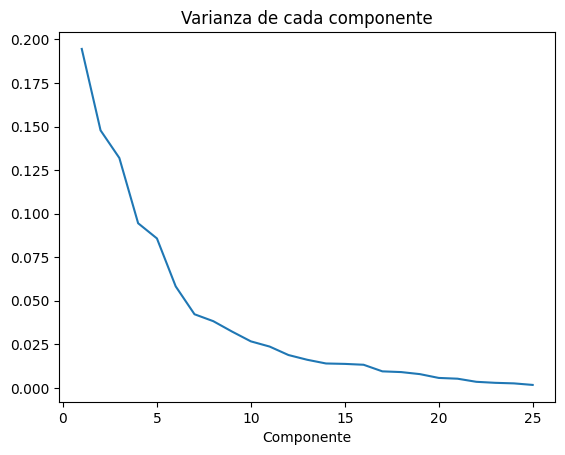

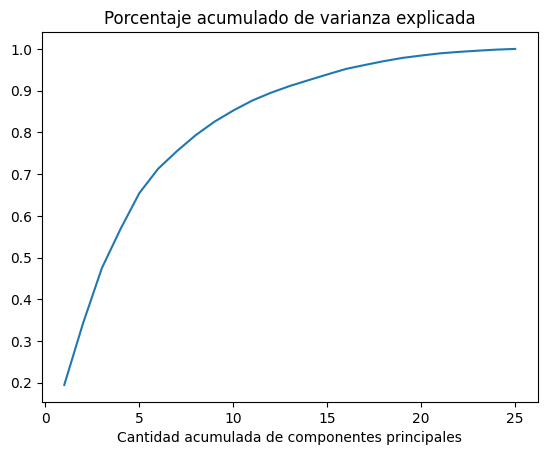

In [56]:

ZTrain,e,loads,eigenvalues,A = PCAR(X_train_bal_clean)

In [57]:
eigenvalues

array([4.8647983 , 3.69579453, 3.29951583, 2.36263648, 2.14480819,
       1.4561757 , 1.05629841, 0.95693654, 0.80750482, 0.6671857 ,
       0.59237124, 0.47113639, 0.40292004, 0.34970232, 0.34379425,
       0.33141011, 0.23666468, 0.22629761, 0.19677088, 0.14229953,
       0.13130614, 0.08666159, 0.07211202, 0.06406305, 0.04192341])

In [60]:
loads

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,0.289847,0.013222,0.208584,0.153303,0.291960,0.134065,0.167295,-0.087604,0.078541,0.081053,...,0.199401,0.156349,0.067270,0.234297,0.137857,0.037979,0.313817,0.285482,0.222329,0.257625
1,0.215258,-0.218702,0.313807,0.353637,0.323504,0.358418,-0.167137,-0.023465,0.028793,-0.196282,...,-0.102786,-0.133637,-0.246461,0.022827,-0.180035,-0.153547,-0.156854,-0.208080,-0.101374,-0.226766
2,-0.082401,0.244165,-0.073434,-0.153842,0.013604,-0.091009,-0.346119,-0.064076,0.099973,0.421366,...,0.138409,-0.222519,0.030133,0.136633,0.098970,-0.018958,0.058148,0.000526,-0.028674,0.039794
3,-0.039718,0.169931,0.037071,0.014147,-0.055520,-0.076219,0.134247,-0.491149,0.029630,0.160613,...,-0.266001,0.069508,0.089383,-0.086820,0.042175,-0.011360,0.043721,-0.115060,-0.407017,-0.298637
4,-0.314414,-0.202920,0.141551,0.181394,-0.005366,0.207183,-0.061999,0.050590,0.498912,0.084102,...,-0.236613,0.108187,0.231009,-0.163282,0.412503,0.307003,-0.235940,0.039074,0.057889,0.137468
5,-0.003800,-0.126183,-0.002414,0.028301,0.048614,0.076287,-0.251454,-0.299911,-0.280532,-0.126222,...,0.110976,0.235010,0.076056,0.216770,-0.114794,0.493084,0.006441,0.372120,-0.271729,0.069145
6,-0.047224,-0.241343,-0.070958,0.150041,-0.076299,0.254219,-0.038848,0.024211,-0.300769,0.050647,...,0.248091,-0.248490,0.612847,-0.256566,0.074052,-0.333525,0.030715,0.135875,-0.184322,-0.000789
7,0.078346,0.306163,0.179380,0.066642,0.105045,-0.134035,-0.033889,-0.264327,0.149514,-0.192017,...,0.352252,-0.261271,0.106143,0.278552,0.399892,-0.130818,-0.265001,-0.029951,0.067242,-0.167162
8,0.118473,0.463233,0.348968,0.194703,-0.040883,-0.161095,-0.207666,0.201424,-0.193059,-0.055944,...,0.022202,0.482127,0.133539,-0.319221,0.074634,-0.005977,-0.075687,-0.058413,-0.127706,-0.035078
9,-0.051711,-0.223135,-0.096128,-0.156827,0.150812,0.027522,0.009090,0.221030,-0.079116,0.080962,...,-0.066340,0.223886,0.157126,0.510875,0.221095,0.010770,0.006956,-0.221621,-0.284319,-0.353917


In [80]:
# se entrena el modelo de regresion logistica con Z_TRAIN
log_reg = LogisticRegression(random_state=42)
log_reg.fit(ZTrain[:, 0:1], y_train_enc)

# se genera croos validation con 5 folds
cv_result_log=cross_validate(log_reg, ZTrain[:, 0:18], y_train_enc, cv=CV, scoring=METRICAS_CV, n_jobs=-1)


In [81]:
cv_result_log

{'fit_time': array([0.62955761, 0.66631722, 0.65684676, 0.6382432 , 0.74762654]),
 'score_time': array([0.00468206, 0.0045476 , 0.00470662, 0.00654674, 0.00540113]),
 'test_f1_weighted': array([0.73699751, 0.75001201, 0.74438143, 0.75691697, 0.74137372]),
 'test_recall_weighted': array([0.73809006, 0.75201218, 0.74592125, 0.75875571, 0.74260226]),
 'test_accuracy': array([0.73809006, 0.75201218, 0.74592125, 0.75875571, 0.74260226])}

In [82]:
resultados_cv['Logistic Regression PCA'] = {
    'F1 Weighted (CV)'    : cv_result_log['test_f1_weighted'].mean(),
    'F1 Weighted Std'     : cv_result_log['test_f1_weighted'].std(),
    'Recall Weighted (CV)': cv_result_log['test_recall_weighted'].mean(),
    'Accuracy (CV)'       : cv_result_log['test_accuracy'].mean()
}

df_cv = pd.DataFrame(resultados_cv).T.sort_values('F1 Weighted (CV)', ascending=False)
print(df_cv.round(4))

                         F1 Weighted (CV)  F1 Weighted Std  \
LightGBM                           0.9899           0.0015   
XGBoost                            0.9867           0.0015   
Random Forest                      0.9864           0.0008   
MLP                                0.9811           0.0028   
SVM                                0.9708           0.0018   
Logistic Regression                0.8006           0.0055   
Logistic Regression PCA            0.7459           0.0069   

                         Recall Weighted (CV)  Accuracy (CV)  
LightGBM                               0.9900         0.9900  
XGBoost                                0.9868         0.9868  
Random Forest                          0.9865         0.9865  
MLP                                    0.9814         0.9814  
SVM                                    0.9716         0.9716  
Logistic Regression                    0.8007         0.8007  
Logistic Regression PCA                0.7475         0.7475  

In [83]:
X_train_bal_clean

,Boro (ppm),Calcio (ppm),Cinc (ppm),Fosforado (ppm),Magnesio (ppm),Molibdeno (ppm),Agua (%),Dilución por combustible (%),Hollín JOAP (Abs/cm),Nitración JOAP (Abs/cm),...,Aluminio (ppm),Cobre (ppm),Cromo (ppm),Estaño (ppm),Hierro (ppm),Plomo (ppm),SACODE_Salud,SACODE_Desgaste,SACODE_Contaminacion,SACODE_General
0,57.390000,1884.000000,1257.000000,1196.000000,347.190000,59.400000,0.0,0.000000,13.000000,6.000000,...,1.070000,1.230000,0.210000,1.070000,4.730000,2.080000,Normal,Normal,Normal,Normal
1,43.640000,3440.728417,1359.057585,1045.309902,21.980000,37.280000,0.0,0.000000,4.000000,9.000000,...,1.790000,0.340000,0.280000,0.000000,3.500000,0.000000,Advertencia,Normal,Normal,Advertencia
2,46.010000,1978.000000,1575.000000,1228.000000,350.510000,70.480000,0.0,0.000000,28.900000,8.000000,...,0.910000,4.310000,0.340000,0.000000,14.510000,20.440000,Normal,Crítico,Crítico,Crítico
3,114.020000,1610.000000,1362.436568,1218.454965,313.700000,63.160000,0.0,0.000000,2.000000,4.000000,...,0.390000,0.230000,0.200000,0.000000,2.710000,0.000000,Normal,Normal,Normal,Normal
4,44.390000,3210.000000,1293.061681,1080.786360,21.030000,33.730000,0.0,0.180000,5.000000,8.000000,...,1.240000,0.450000,0.400000,0.000000,3.630000,0.460000,Normal,Normal,Normal,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22979,79.984138,1481.279748,1317.896456,1089.149878,256.282071,54.338484,0.0,0.409463,10.560548,4.109863,...,0.226318,1.405855,0.030762,0.000000,2.780962,0.000000,Normal,Normal,Normal,Normal
22980,63.262807,1697.297336,1351.745657,1244.268297,316.470898,59.202862,0.0,0.494863,18.371576,6.000000,...,0.272584,1.440179,0.360453,0.072116,5.918872,0.041874,Normal,Normal,Normal,Normal
22981,84.859816,1711.685859,1418.636309,1275.392232,324.683515,66.596097,0.0,0.192041,10.801015,5.342930,...,0.958772,0.683531,0.393429,0.000000,3.859153,0.000000,Normal,Normal,Normal,Normal
22982,67.541239,1632.070752,1338.664467,1196.096622,294.653236,57.474962,0.0,0.528387,17.154831,5.367740,...,0.129935,1.584710,0.273548,0.000000,5.316577,0.000000,Normal,Normal,Normal,Normal


#### Consideraciones Importantes

Si bien los modelos de ML  escogidos en  evidencian una buena respuesta en ellas pruebas de Test y entrenamiento en las validaciones cruzadas realizadas , es posible observar que en las pruebas de test al escoger un modo de falla como critico tal como lo es la presencia de metales , el indicador de recall disminuyes drasticamente . Este modo de falla en los motores diesel es de alta criticidad debido a que puede estar indicando el incio de un modod de falla que conlleve a la destruccion del componete , es por este que el indicador de recall ( identificacion de verdaderos positivos) es de alta criticidad , debido que para el negocio es mas favorbale tener un incrmento de alertas que puedan ser validadas por los analistas en vez de dejar pasar alertas y se materialice la falla. 

En vista de este hallazgo , a continuacion se  realizaran los siguintes proccedimientos en busca de aumentar este indicador y manteniendo el resto 

1. Se realizara un analisis de como es el comportamiento de como es la distrivuccion entre los elementos metalicos  entre las diferentes flota , si bien el cliente no especifico que este comportamiento puede cambiar , se realizara una validacion apartir de los histogramas realizados. 

2. En caso de identificar diferencias significativos entre comportamientos , se relizara la calificacion de noria con base a los limites calculados de cada flota.




In [89]:
data_cleaned

,Unnamed: 0,Flota,Rule Based Rating,Assigned Condition Rating,Fault Effect,Boro (ppm),Calcio (ppm),Cinc (ppm),Fosforado (ppm),Magnesio (ppm),...,Cobre (ppm),Cromo (ppm),Estaño (ppm),Hierro (ppm),Plomo (ppm),SACODE_Salud,SACODE_Desgaste,SACODE_Contaminacion,SACODE_General,ACR_Homologado
0,1,Flota_2,Normal,Normal,No Fault Identified,111.67,1691.0,1546.422837,1408.484493,376.800000,...,0.10,0.16,0.000000,2.84,0.09,Advertencia,Normal,Normal,Advertencia,Normal
1,2,Flota_2,Normal,Normal,No Fault Identified,90.69,1712.0,1556.664839,1385.410514,362.750000,...,0.35,0.05,0.000000,2.55,0.17,Advertencia,Normal,Normal,Advertencia,Normal
2,5,Flota_2,Normal,Normal,No Fault Identified,95.43,1718.0,1574.171999,1391.718333,357.640000,...,0.38,0.07,0.000000,3.12,0.65,Advertencia,Normal,Normal,Advertencia,Normal
3,7,Flota_2,Normal,Normal,No Fault Identified,117.17,1610.0,1425.210407,1275.209293,343.310000,...,0.15,0.01,0.000000,1.86,0.57,Normal,Normal,Normal,Normal,Normal
4,9,Flota_3,Normal,Normal,No Fault Identified,113.43,1622.0,1415.885054,1297.927423,338.570000,...,0.16,0.17,0.000000,2.35,0.24,Normal,Normal,Normal,Normal,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4278,4292,Flota_1,Normal,Normal,No Fault Identified,0.20,1293.0,1227.613822,1162.162851,158.030293,...,1.00,0.40,0.126293,3.00,2.20,Normal,Normal,Normal,Normal,Normal
4279,4293,Flota_2,Normal,Normal,No Fault Identified,0.20,1338.0,1231.664468,1161.943412,157.159753,...,1.00,0.30,0.435444,3.00,1.50,Normal,Normal,Normal,Normal,Normal
4280,4294,Flota_1,Warning,Warning,Fluid Condition Deteriorating,0.30,1343.0,1262.213139,1155.770797,146.138833,...,1.30,0.70,0.078613,6.00,9.10,Normal,Crítico,Normal,Crítico,Advertencia
4281,4295,Flota_1,Warning,Warning,Fluid Condition Deteriorating,0.40,1331.0,1250.710223,1157.318012,142.924328,...,7.60,0.80,0.000000,6.00,2.50,Normal,Advertencia,Normal,Advertencia,Advertencia


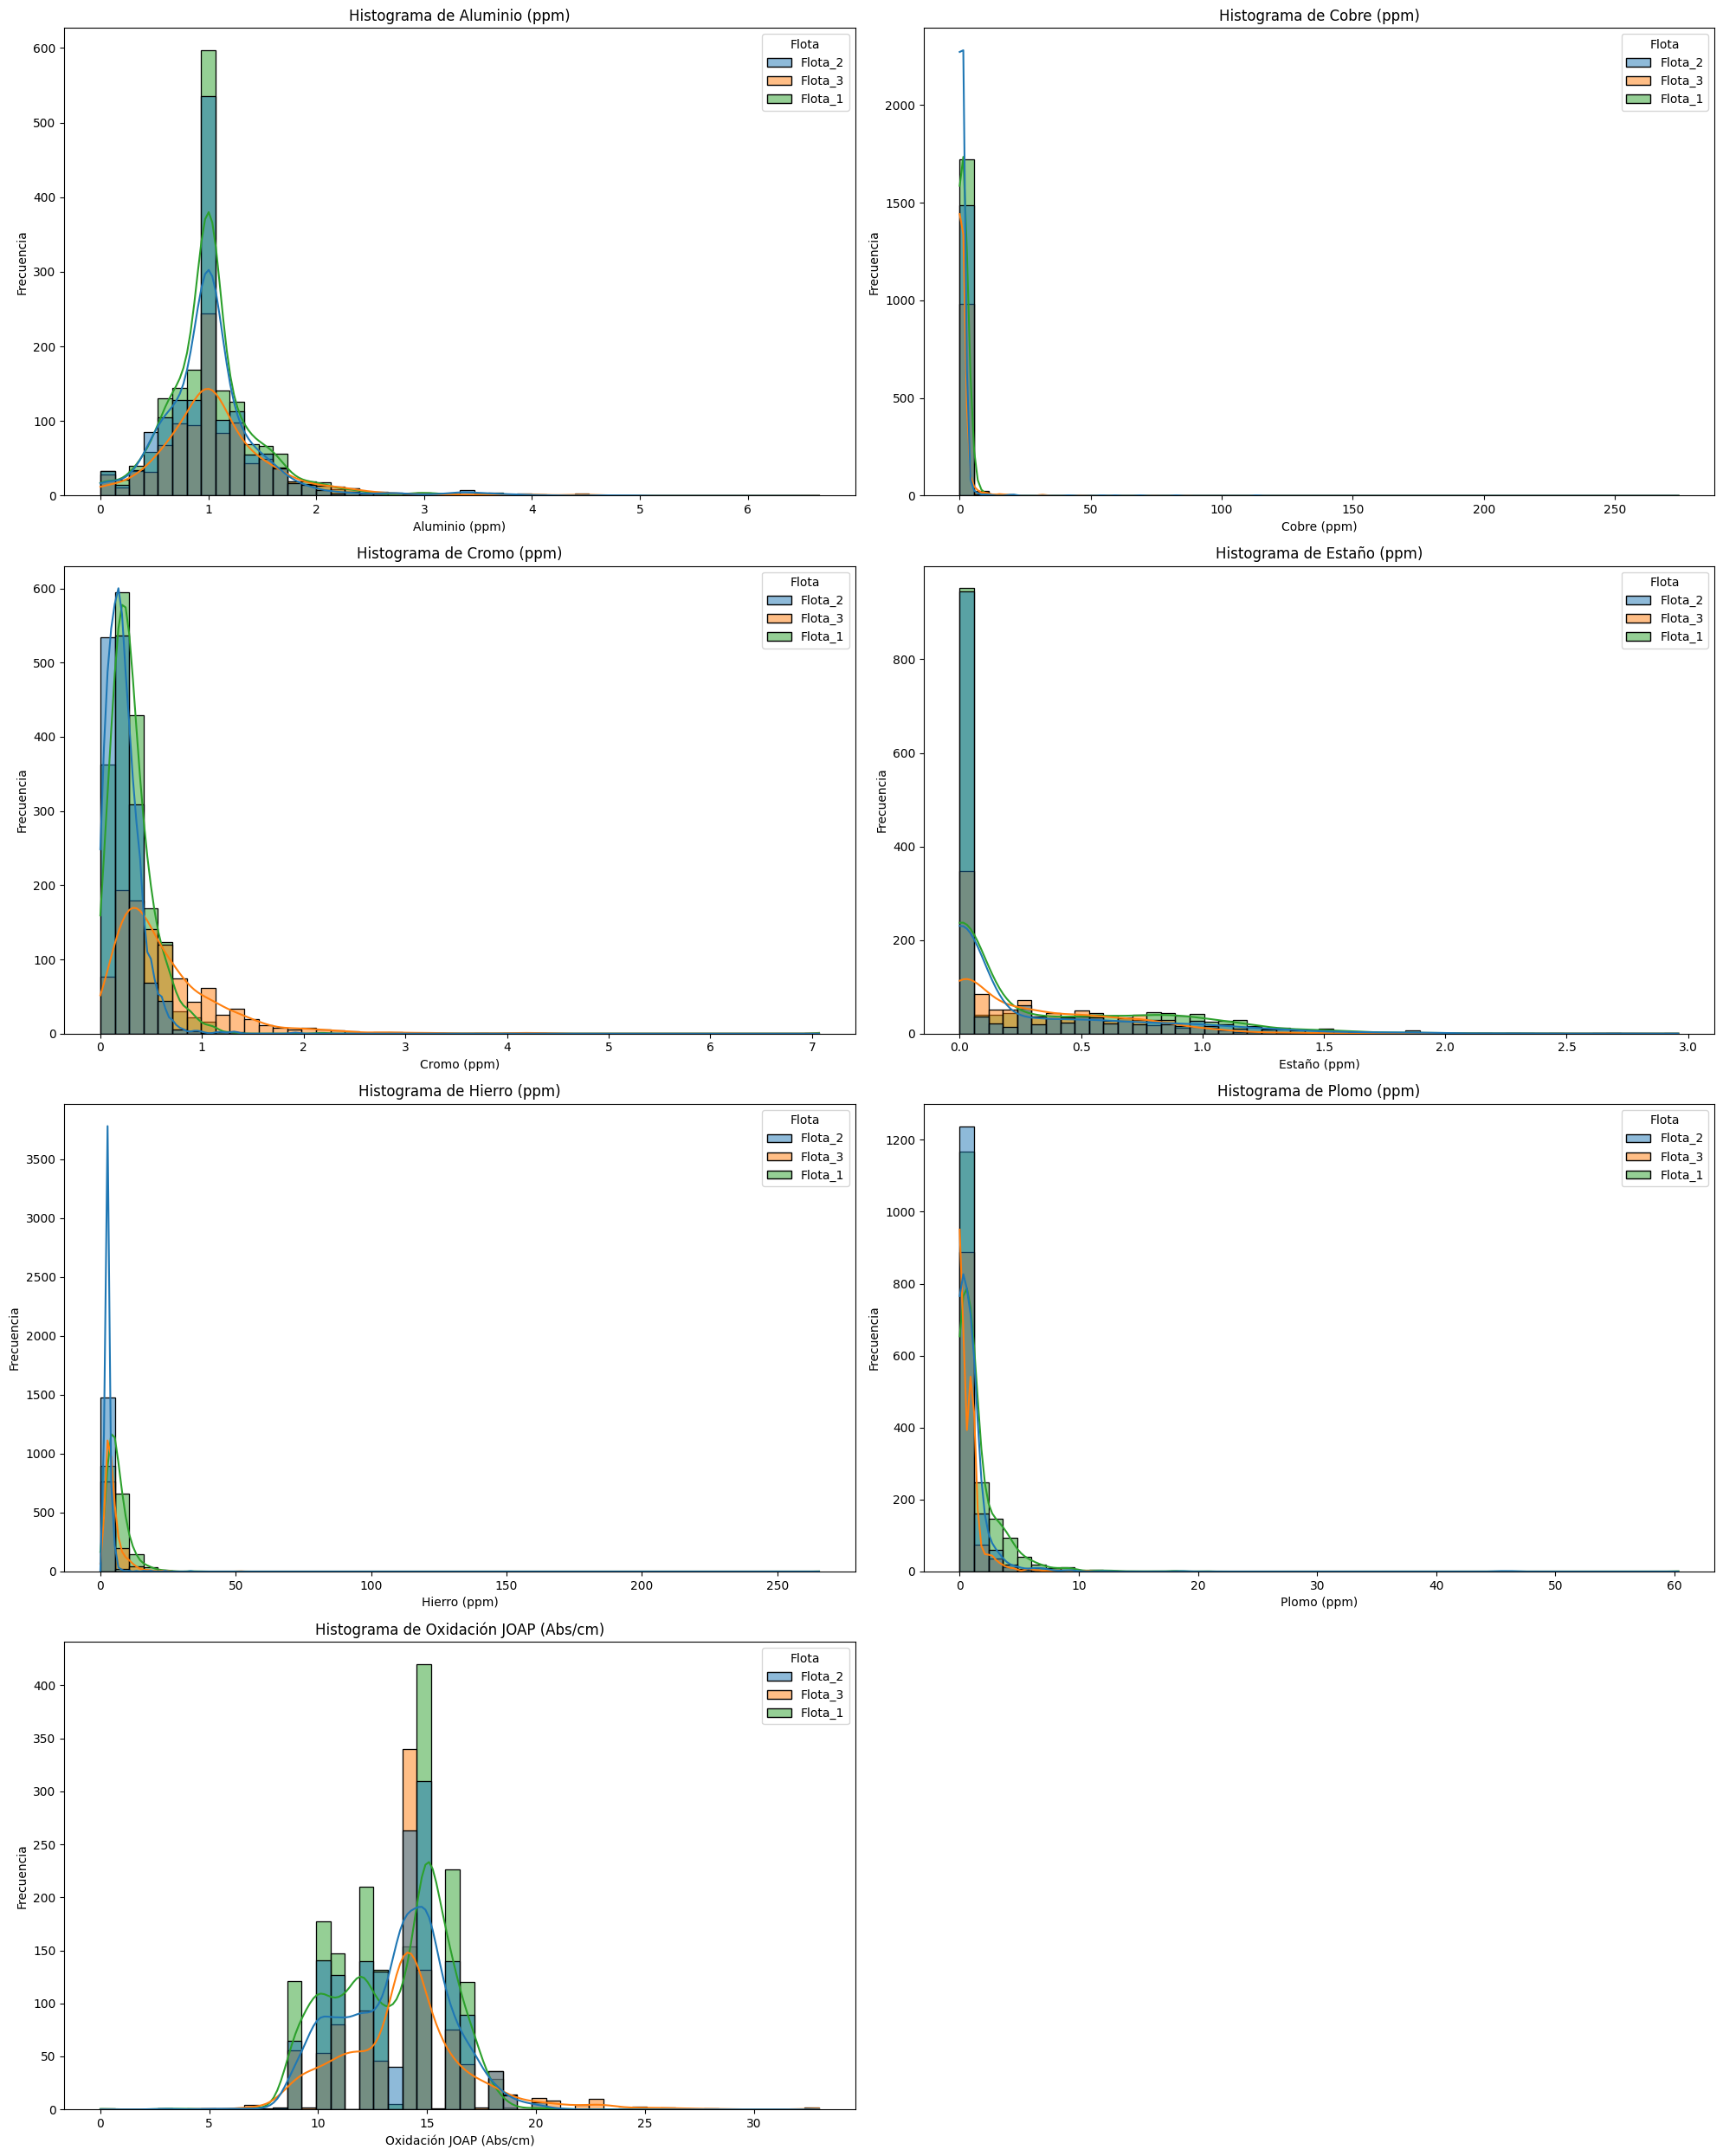

In [93]:
import seaborn as sns

Desgaste = data_cleaned[['Aluminio (ppm)', 'Cobre (ppm)', 'Cromo (ppm)', 'Estaño (ppm)',
                          'Hierro (ppm)', 'Plomo (ppm)',
                          'Oxidación JOAP (Abs/cm)']]

# Determinar el tamaño de la cuadrícula
n_cols = 2
n_rows =4  # Redondeo hacia arriba para que haya suficiente espacio

# Crear la figura y los ejes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 25))
axes = axes.flatten()  # Aplanar los ejes para iterar sobre ellos fácilmente

# Generar un histograma para cada columna numérica
for i, col in enumerate(Desgaste):
    sns.histplot(data=data_cleaned, bins=50, x=col, hue='Flota', kde=True, ax=axes[i])
    axes[i].set_title(f'Histograma de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

# Eliminar cualquier gráfico extra (en caso de que haya más subplots que columnas)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ajustar el espaciado entre gráficos
plt.tight_layout()
plt.show()

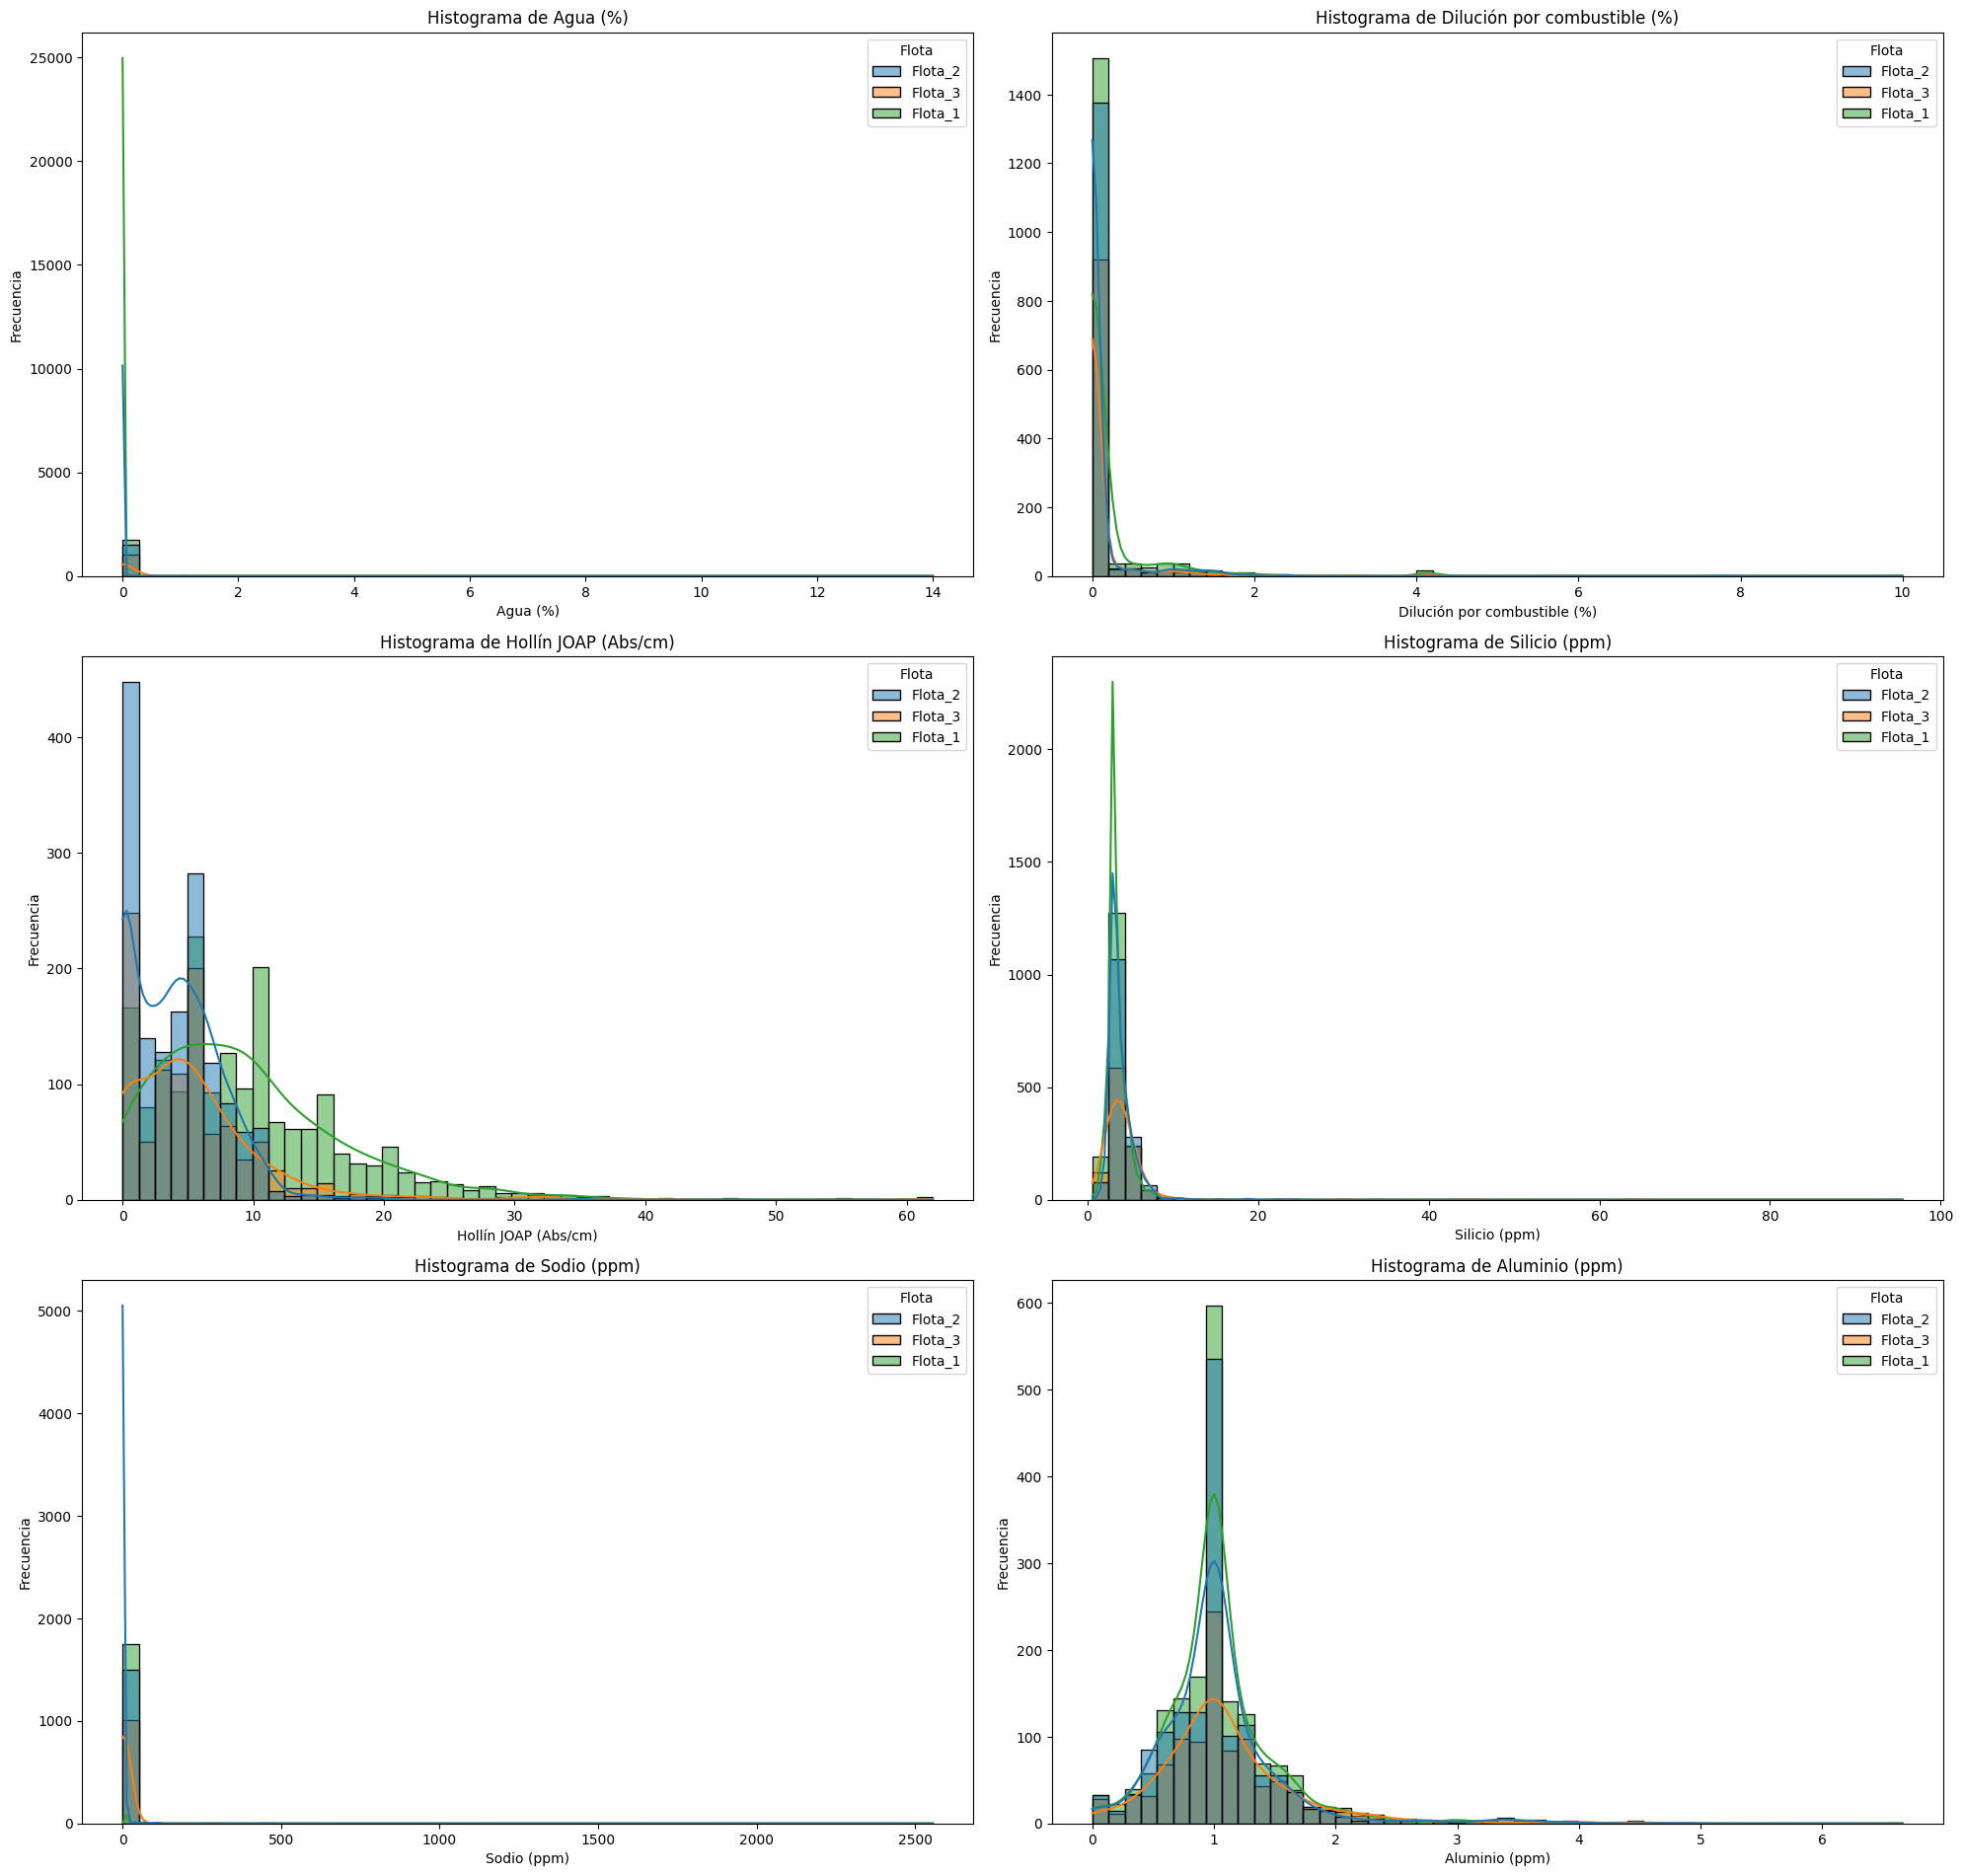

In [97]:
import seaborn as sns

Contaminacion = data_cleaned[['Agua (%)', 'Dilución por combustible (%)',
                               'Hollín JOAP (Abs/cm)', 'Silicio (ppm)',
                               'Sodio (ppm)', 'Aluminio (ppm)']]

# Determinar el tamaño de la cuadrícula
n_cols = 2
n_rows =4  # Redondeo hacia arriba para que haya suficiente espacio

# Crear la figura y los ejes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 25))
axes = axes.flatten()  # Aplanar los ejes para iterar sobre ellos fácilmente

# Generar un histograma para cada columna numérica
for i, col in enumerate(Contaminacion):
    sns.histplot(data=data_cleaned, bins=50, x=col, hue='Flota', kde=True, ax=axes[i])
    axes[i].set_title(f'Histograma de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

# Eliminar cualquier gráfico extra (en caso de que haya más subplots que columnas)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ajustar el espaciado entre gráficos
plt.tight_layout()
plt.show()

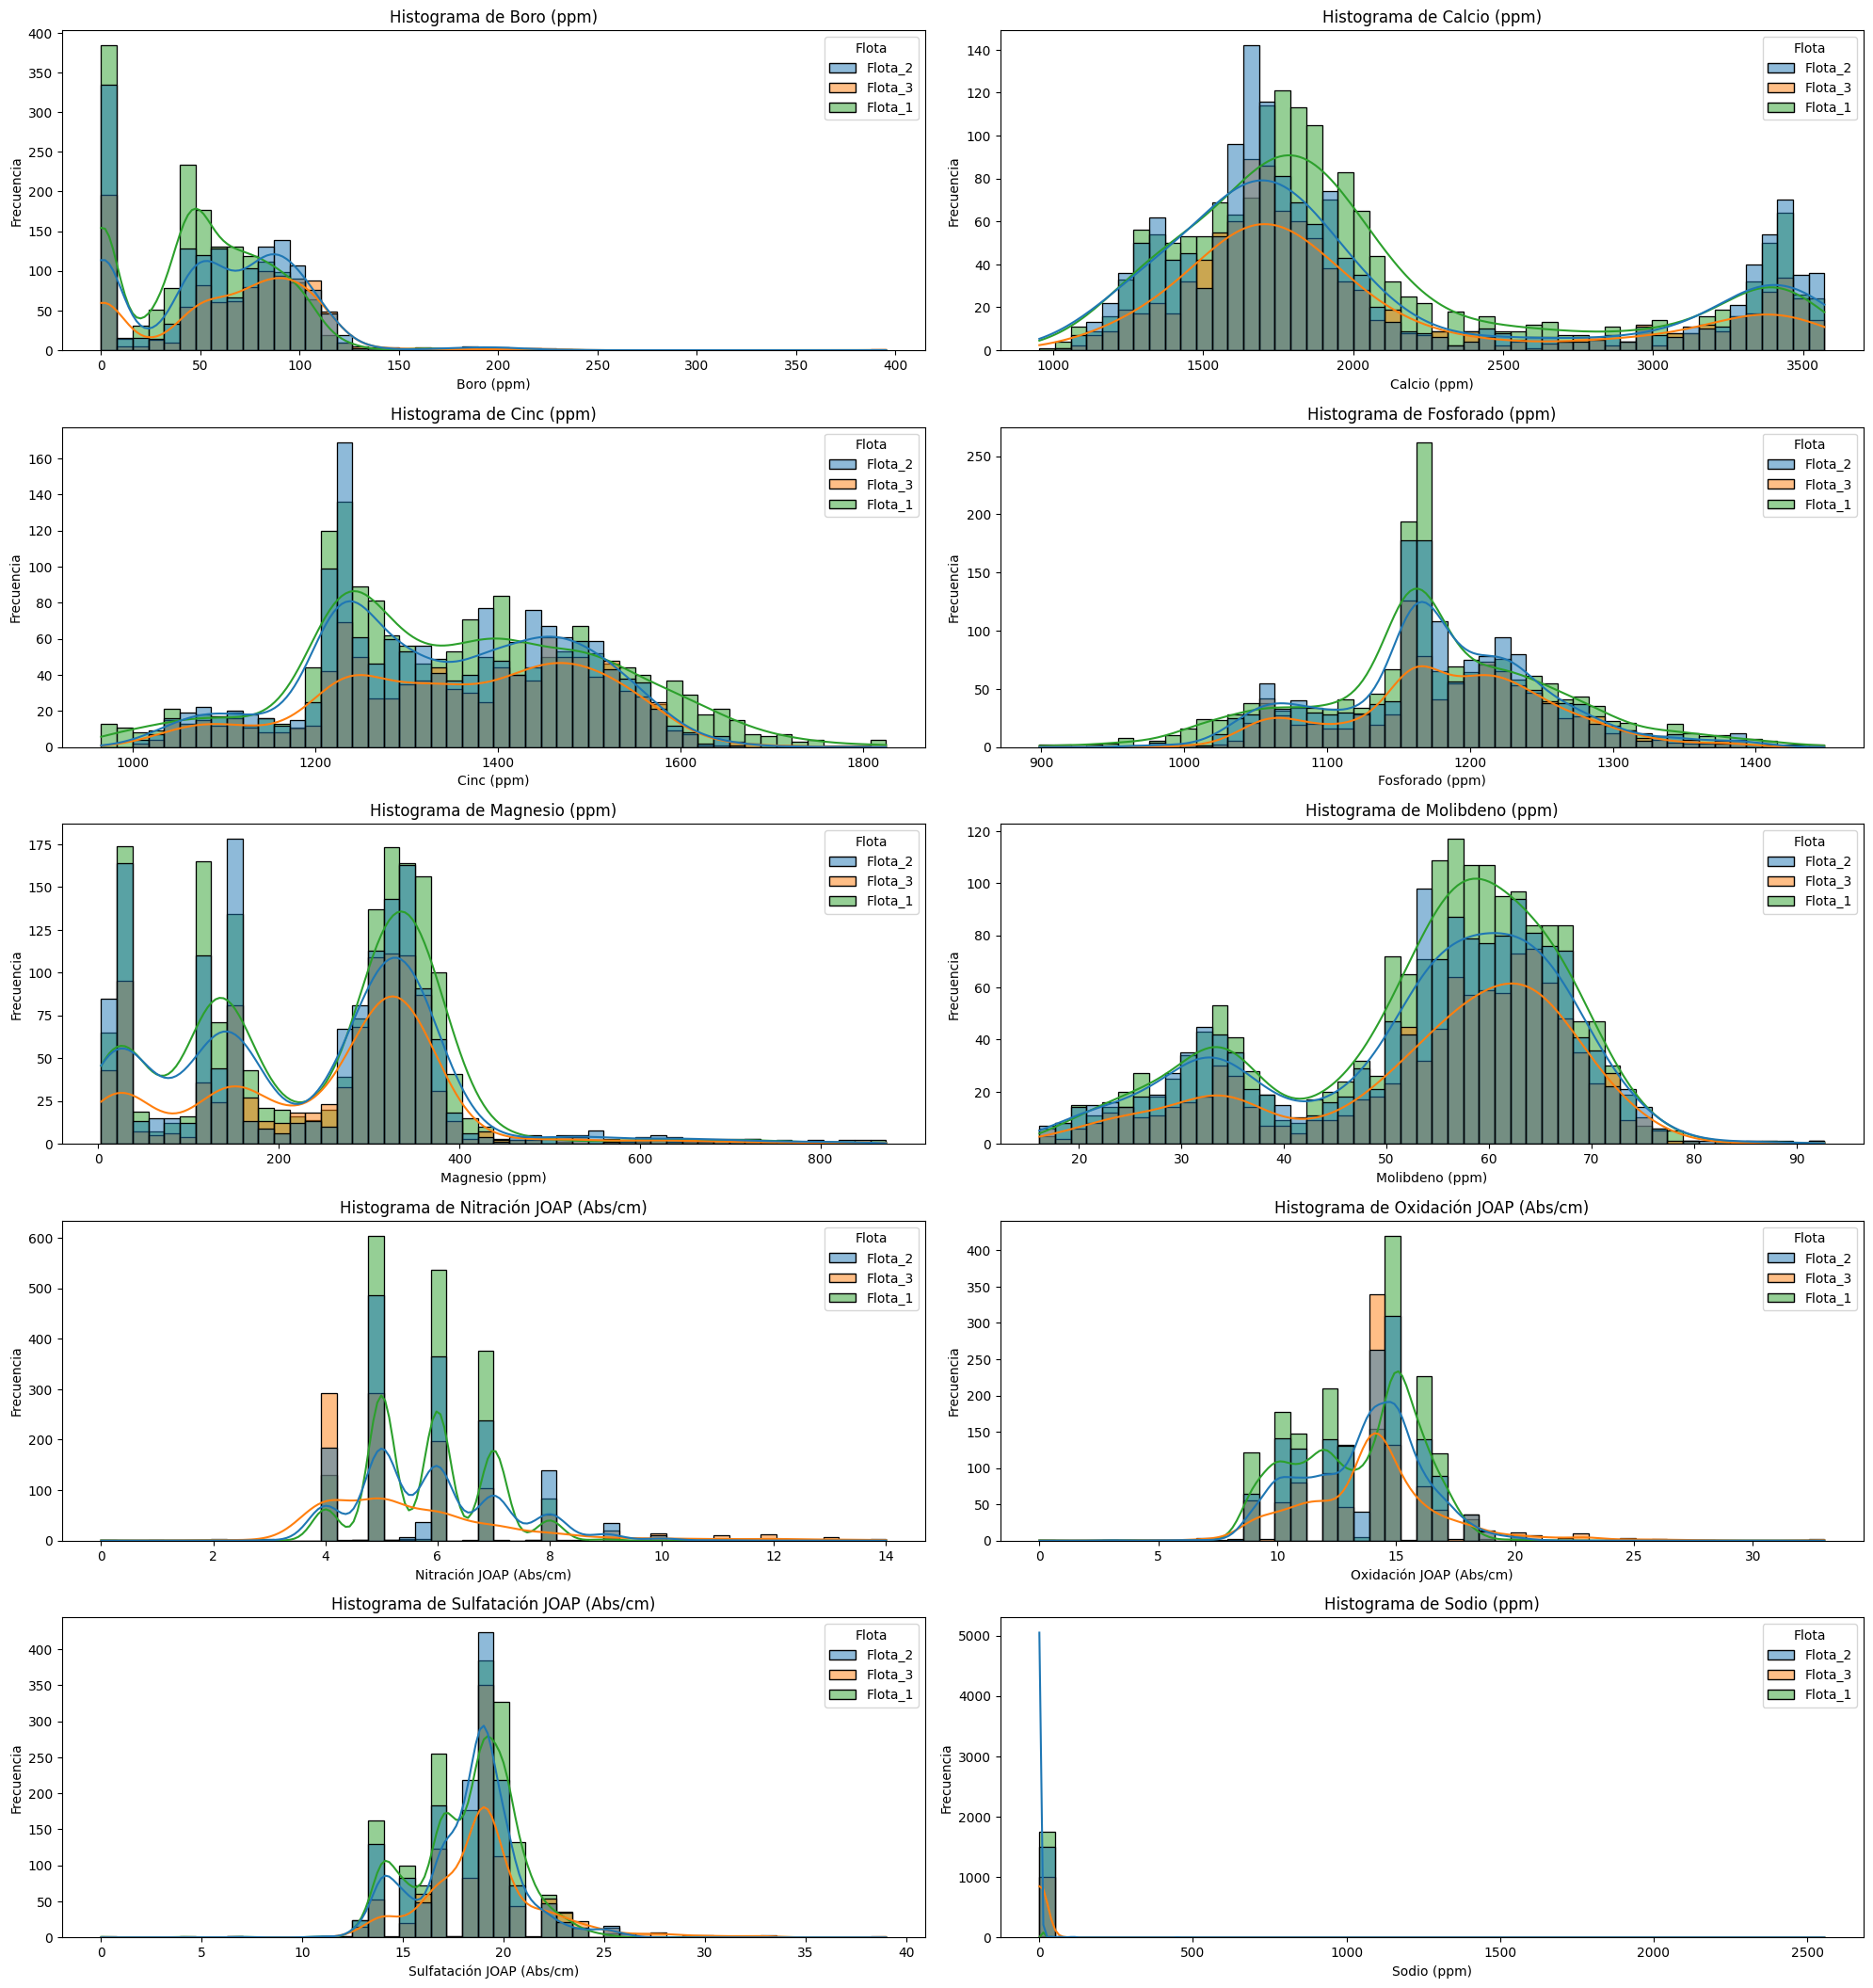

In [99]:
Salud = data_cleaned[['Boro (ppm)', 'Calcio (ppm)', 'Cinc (ppm)', 'Fosforado (ppm)',
                       'Magnesio (ppm)', 'Molibdeno (ppm)', 'Nitración JOAP (Abs/cm)',
                       'Oxidación JOAP (Abs/cm)', 'Sulfatación JOAP (Abs/cm)', 'Sodio (ppm)']]

# Determinar el tamaño de la cuadrícula
n_cols = 2
n_rows =6  # Redondeo hacia arriba para que haya suficiente espacio

# Crear la figura y los ejes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 25))
axes = axes.flatten()  # Aplanar los ejes para iterar sobre ellos fácilmente

# Generar un histograma para cada columna numérica
for i, col in enumerate(Salud):
    sns.histplot(data=data_cleaned, bins=50, x=col, hue='Flota', kde=True, ax=axes[i])
    axes[i].set_title(f'Histograma de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

# Eliminar cualquier gráfico extra (en caso de que haya más subplots que columnas)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ajustar el espaciado entre gráficos
plt.tight_layout()
plt.show()

**Nota.**Con base al analisis de distribuccion se observa que los predictotes contenidos en la metodologia de SACODE presentan comportamientos diferenciales , entre si, por tal razon se proccede a realizar estas consideraciones

1. Se calcula los limites de la metodologia de SACODE basado en el comportamiento de cada flota 
2. Se geneneran modelos diferentes para cada tipo de flota basado en el comportamiento diferencial de los predictores 

CALIFICACIÓN SACODE POR FLOTA

───────────────────────────────────────────────────────
  Flota : Flota_1  (1753 registros)
───────────────────────────────────────────────────────

  SACODE_Salud:
    Normal      : 1394  (79.5%)
    Advertencia :  325  (18.5%)
    Crítico     :   34  (1.9%)

  SACODE_Desgaste:
    Normal      : 1437  (82.0%)
    Advertencia :  213  (12.2%)
    Crítico     :  103  (5.9%)

  SACODE_Contaminacion:
    Normal      : 1472  (84.0%)
    Advertencia :  167  (9.5%)
    Crítico     :  114  (6.5%)

  SACODE_General:
    Normal      : 1019  (58.1%)
    Advertencia :  524  (29.9%)
    Crítico     :  210  (12.0%)

───────────────────────────────────────────────────────
  Flota : Flota_2  (1508 registros)
───────────────────────────────────────────────────────

  SACODE_Salud:
    Normal      : 1302  (86.3%)
    Advertencia :  156  (10.3%)
    Crítico     :   50  (3.3%)

  SACODE_Desgaste:
    Normal      : 1282  (85.0%)
    Advertencia :  137  (9.1%)
    Crítico     

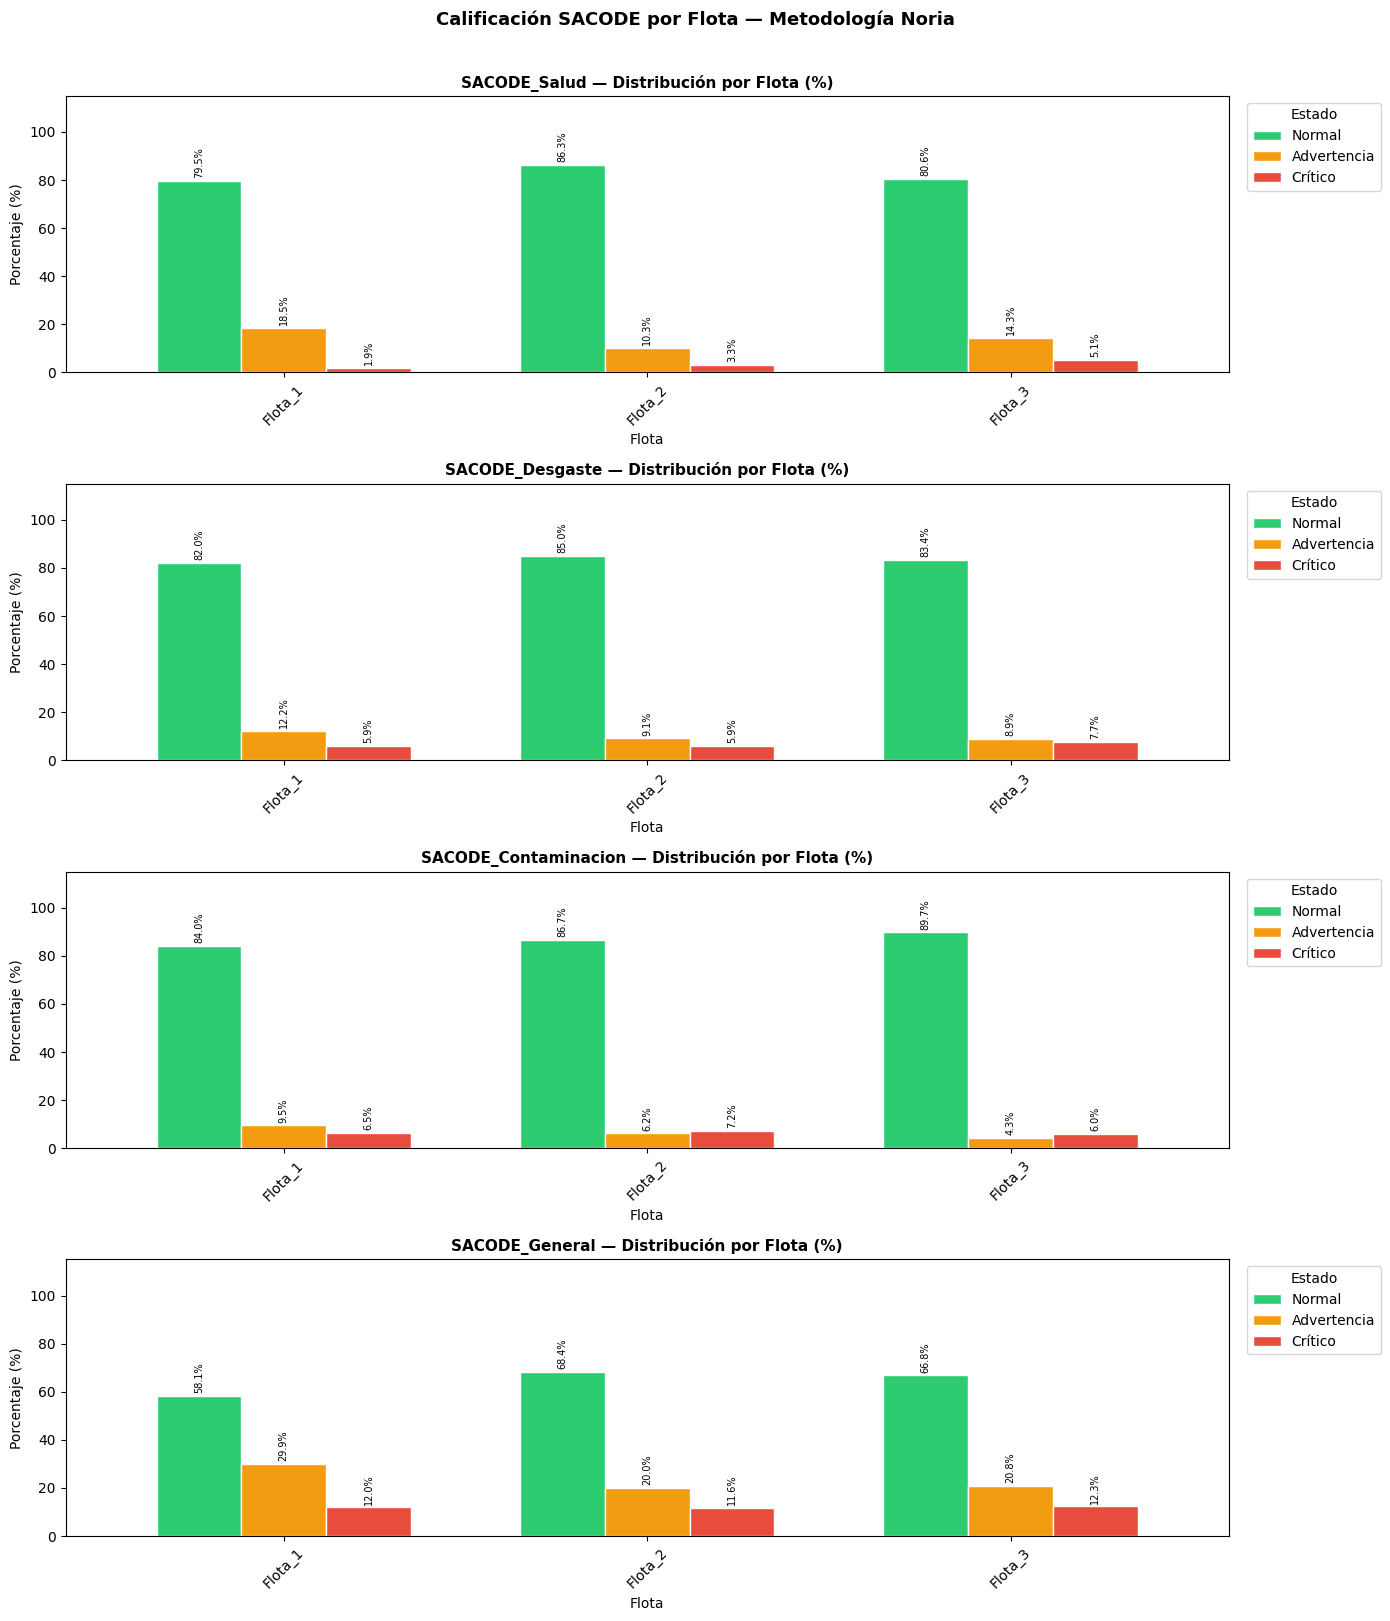


=== Límites Condenatorios por Flota (Salud — lim_warn_sup) ===
                            Flota_1   Flota_2   Flota_3
Boro (ppm)                  121.577   141.418   150.308
Calcio (ppm)               3365.749  3522.033  3383.415
Cinc (ppm)                 1675.915  1619.474  1648.434
Fosforado (ppm)            1347.849  1326.178  1329.709
Magnesio (ppm)              522.416   528.290   529.843
Molibdeno (ppm)              80.978    81.870    82.503
Nitración JOAP (Abs/cm)       7.909     8.474     9.310
Oxidación JOAP (Abs/cm)      19.000    19.000    19.000
Sulfatación JOAP (Abs/cm)    23.196    23.116    25.082
Sodio (ppm)                  40.000    40.000    40.000


In [100]:
import pandas as pd
import numpy as np

data_cleaned=data_cleaned.drop(columns=['Unnamed: 0','SACODE_Salud','SACODE_Desgaste','SACODE_Contaminacion','SACODE_General'])



COLS_SALUD = [
    'Boro (ppm)', 'Calcio (ppm)', 'Cinc (ppm)', 'Fosforado (ppm)',
    'Magnesio (ppm)', 'Molibdeno (ppm)', 'Nitración JOAP (Abs/cm)',
    'Oxidación JOAP (Abs/cm)', 'Sulfatación JOAP (Abs/cm)', 'Sodio (ppm)'
]

COLS_DESGASTE = [
    'Aluminio (ppm)', 'Cobre (ppm)', 'Cromo (ppm)', 'Estaño (ppm)',
    'Hierro (ppm)', 'Plomo (ppm)', 'Oxidación JOAP (Abs/cm)'
]

COLS_CONTAMINACION = [
    'Agua (%)', 'Dilución por combustible (%)',
    'Hollín JOAP (Abs/cm)', 'Silicio (ppm)',
    'Sodio (ppm)', 'Aluminio (ppm)'
]


AJUSTES_CLIENTE = {
    'salud': {
        'Sodio (ppm)'              : {'lim_warn_sup': 40,  'lim_critico_sup': 100},
        'Oxidación JOAP (Abs/cm)'  : {'lim_warn_sup': 19,  'lim_critico_sup': 21},
    },
    'desgaste': {
        'Cobre (ppm)'              : {'lim_warn_sup': 6,   'lim_critico_sup': 8},
        'Plomo (ppm)'              : {'lim_warn_sup': 4,   'lim_critico_sup': 6},
    },
    'contaminacion': {}
}

# ------------------------------------------------------------------------------
# Funciones SACODE
# ------------------------------------------------------------------------------

def calcular_limites(df: pd.DataFrame,
                     factor_warning: float = 2.0,
                     factor_critico: float = 3.0) -> pd.DataFrame:
    """Calcula límites condenatorios por desviación estándar (Metodología Noria)."""
    stats = pd.DataFrame({
        'media'           : df.mean(),
        'sigma'           : df.std(),
        'lim_warn_sup'    : df.mean() + factor_warning * df.std(),
        'lim_warn_inf'    : (df.mean() - factor_warning * df.std()).clip(lower=0),
        'lim_critico_sup' : df.mean() + factor_critico * df.std(),
        'lim_critico_inf' : (df.mean() - factor_critico * df.std()).clip(lower=0),
    })
    return stats


def aplicar_ajustes_cliente(limites: pd.DataFrame,
                             ajustes: dict) -> pd.DataFrame:
    limites = limites.copy()
    for col, vals in ajustes.items():
        if col in limites.index:
            for campo, valor in vals.items():
                limites.loc[col, campo] = valor
    return limites


def clasificar_predictor(valor: float,
                          lim_warn_sup: float,
                          lim_critico_sup: float) -> str:
    if valor <= lim_warn_sup:
        return 'Normal'
    elif valor <= lim_critico_sup:
        return 'Advertencia'
    else:
        return 'Crítico'


def calificar_categoria(df: pd.DataFrame,
                         limites: pd.DataFrame) -> pd.Series:
    orden_severidad = {'Normal': 0, 'Advertencia': 1, 'Crítico': 2}
    inv_orden       = {v: k for k, v in orden_severidad.items()}

    calificaciones = pd.DataFrame(index=df.index)
    for col in df.columns:
        lim_w = limites.loc[col, 'lim_warn_sup']
        lim_c = limites.loc[col, 'lim_critico_sup']
        calificaciones[col] = df[col].apply(
            lambda x: clasificar_predictor(x, lim_w, lim_c)
        )

    peor_caso = calificaciones.map(lambda x: orden_severidad[x]).max(axis=1)
    return peor_caso.map(inv_orden)


# ------------------------------------------------------------------------------
# Cálculo SACODE por Flota
# ------------------------------------------------------------------------------

flotas         = data_cleaned['Flota'].unique()
limites_flota  = {}   # Almacena límites calculados por flota y categoría
resultados     = []   # Acumula filas clasificadas

print("=" * 65)
print("CALIFICACIÓN SACODE POR FLOTA")
print("=" * 65)

for flota in sorted(flotas):

    df_flota = data_cleaned[data_cleaned['Flota'] == flota].copy()
    n        = len(df_flota)

    if n < 30:
        print(f"\n⚠️  Flota '{flota}' omitida — solo {n} registros (mínimo 30)")
        continue

    print(f"\n{'─'*55}")
    print(f"  Flota : {flota}  ({n} registros)")
    print(f"{'─'*55}")

    # Subsets por categoría
    salud_f        = df_flota[COLS_SALUD]
    desgaste_f     = df_flota[COLS_DESGASTE]
    contaminacion_f = df_flota[COLS_CONTAMINACION]

    # Cálculo de límites estadísticos
    lim_salud        = calcular_limites(salud_f)
    lim_desgaste     = calcular_limites(desgaste_f)
    lim_contaminacion = calcular_limites(contaminacion_f)

    # Aplicar ajustes del cliente
    lim_salud        = aplicar_ajustes_cliente(lim_salud,        AJUSTES_CLIENTE['salud'])
    lim_desgaste     = aplicar_ajustes_cliente(lim_desgaste,     AJUSTES_CLIENTE['desgaste'])
    lim_contaminacion = aplicar_ajustes_cliente(lim_contaminacion, AJUSTES_CLIENTE['contaminacion'])

    # Guardar límites para trazabilidad
    limites_flota[flota] = {
        'salud'        : lim_salud,
        'desgaste'     : lim_desgaste,
        'contaminacion': lim_contaminacion
    }

    # Clasificación SACODE
    df_flota['SACODE_Salud']         = calificar_categoria(salud_f,         lim_salud)
    df_flota['SACODE_Desgaste']      = calificar_categoria(desgaste_f,      lim_desgaste)
    df_flota['SACODE_Contaminacion'] = calificar_categoria(contaminacion_f, lim_contaminacion)

    # Calificación general — peor caso entre las 3 categorías
    orden_sev  = {'Normal': 0, 'Advertencia': 1, 'Crítico': 2}
    inv_orden  = {v: k for k, v in orden_sev.items()}
    sev_num    = df_flota[['SACODE_Salud', 'SACODE_Desgaste', 'SACODE_Contaminacion']]\
                     .map(lambda x: orden_sev[x])
    df_flota['SACODE_General'] = sev_num.max(axis=1).map(inv_orden)

    # Resumen de distribución
    for cat in ['SACODE_Salud', 'SACODE_Desgaste', 'SACODE_Contaminacion', 'SACODE_General']:
        dist = df_flota[cat].value_counts()
        pct  = df_flota[cat].value_counts(normalize=True).mul(100).round(1)
        print(f"\n  {cat}:")
        for estado in ['Normal', 'Advertencia', 'Crítico']:
            cnt = dist.get(estado, 0)
            p   = pct.get(estado, 0.0)
            print(f"    {estado:12s}: {cnt:4d}  ({p:.1f}%)")

    resultados.append(df_flota)

# ------------------------------------------------------------------------------
# Consolidación en data_cleaned
# ------------------------------------------------------------------------------

df_consolidado = pd.concat(resultados, axis=0).sort_index()

# Asignar de vuelta al dataset original respetando el índice
for col in ['SACODE_Salud', 'SACODE_Desgaste', 'SACODE_Contaminacion', 'SACODE_General']:
    data_cleaned[col] = df_consolidado[col]

print(f"\n{'='*65}")
print(f"✅ Calificación SACODE asignada: {len(df_consolidado)} registros")
print(f"   Flotas procesadas : {len(limites_flota)}")
print(f"   Columnas nuevas   : SACODE_Salud, SACODE_Desgaste, "
      f"SACODE_Contaminacion, SACODE_General")

# ------------------------------------------------------------------------------
# Visualización comparativa entre flotas
# ------------------------------------------------------------------------------

orden   = ['Normal', 'Advertencia', 'Crítico']
colores = {'Normal': '#2ecc71', 'Advertencia': '#f39c12', 'Crítico': '#e74c3c'}
cats    = ['SACODE_Salud', 'SACODE_Desgaste', 'SACODE_Contaminacion', 'SACODE_General']

fig, axes = plt.subplots(len(cats), 1,
                          figsize=(14, len(cats) * 4),
                          sharex=False)

for ax, cat in zip(axes, cats):
    tabla = (data_cleaned.groupby('Flota')[cat]
                         .value_counts(normalize=True)
                         .mul(100)
                         .unstack(fill_value=0)
                         .reindex(columns=orden, fill_value=0))

    tabla.plot(kind='bar', ax=ax,
               color=[colores[c] for c in orden],
               edgecolor='white', width=0.7)

    ax.set_title(f'{cat} — Distribución por Flota (%)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Flota')
    ax.set_ylabel('Porcentaje (%)')
    ax.set_ylim(0, 115)
    ax.legend(title='Estado', bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.tick_params(axis='x', rotation=45)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=7,
                     padding=2, rotation=90)

plt.suptitle('Calificación SACODE por Flota — Metodología Noria',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# Tabla de límites por flota — Trazabilidad
# ------------------------------------------------------------------------------

print("\n=== Límites Condenatorios por Flota (Salud — lim_warn_sup) ===")
tabla_limites = pd.DataFrame({
    flota: limites_flota[flota]['salud']['lim_warn_sup']
    for flota in limites_flota
}).round(3)
print(tabla_limites)

### Modelo para la Flota 1


In [101]:
df_consolidado

,Flota,Rule Based Rating,Assigned Condition Rating,Fault Effect,Boro (ppm),Calcio (ppm),Cinc (ppm),Fosforado (ppm),Magnesio (ppm),Molibdeno (ppm),...,Cobre (ppm),Cromo (ppm),Estaño (ppm),Hierro (ppm),Plomo (ppm),ACR_Homologado,SACODE_Salud,SACODE_Desgaste,SACODE_Contaminacion,SACODE_General
0,Flota_2,Normal,Normal,No Fault Identified,111.67,1691.0,1546.422837,1408.484493,376.800000,70.01,...,0.10,0.16,0.000000,2.84,0.09,Normal,Crítico,Normal,Normal,Crítico
1,Flota_2,Normal,Normal,No Fault Identified,90.69,1712.0,1556.664839,1385.410514,362.750000,68.89,...,0.35,0.05,0.000000,2.55,0.17,Normal,Advertencia,Normal,Normal,Advertencia
2,Flota_2,Normal,Normal,No Fault Identified,95.43,1718.0,1574.171999,1391.718333,357.640000,68.65,...,0.38,0.07,0.000000,3.12,0.65,Normal,Advertencia,Normal,Normal,Advertencia
3,Flota_2,Normal,Normal,No Fault Identified,117.17,1610.0,1425.210407,1275.209293,343.310000,70.61,...,0.15,0.01,0.000000,1.86,0.57,Normal,Normal,Normal,Normal,Normal
4,Flota_3,Normal,Normal,No Fault Identified,113.43,1622.0,1415.885054,1297.927423,338.570000,68.19,...,0.16,0.17,0.000000,2.35,0.24,Normal,Normal,Normal,Normal,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4278,Flota_1,Normal,Normal,No Fault Identified,0.20,1293.0,1227.613822,1162.162851,158.030293,55.10,...,1.00,0.40,0.126293,3.00,2.20,Normal,Normal,Normal,Normal,Normal
4279,Flota_2,Normal,Normal,No Fault Identified,0.20,1338.0,1231.664468,1161.943412,157.159753,57.70,...,1.00,0.30,0.435444,3.00,1.50,Normal,Normal,Normal,Normal,Normal
4280,Flota_1,Warning,Warning,Fluid Condition Deteriorating,0.30,1343.0,1262.213139,1155.770797,146.138833,45.80,...,1.30,0.70,0.078613,6.00,9.10,Advertencia,Normal,Crítico,Normal,Crítico
4281,Flota_1,Warning,Warning,Fluid Condition Deteriorating,0.40,1331.0,1250.710223,1157.318012,142.924328,52.50,...,7.60,0.80,0.000000,6.00,2.50,Advertencia,Normal,Advertencia,Normal,Advertencia


In [105]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

df_flota1=data_cleaned[data_cleaned['Flota']=='Flota_1']
# Variables predictoras y variable objetivo
X = df_flota1.drop(columns=['Assigned Condition Rating',
                             'ACR_Homologado',
                             'Assigned Condition Rating',
                             'Fault Effect',
                                'SACODE_Salud',
                                'SACODE_Desgaste',
                                'SACODE_Contaminacion',
                                'SACODE_General','Flota','Rule Based Rating'])

y = df_flota1['Fault Effect']


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y       
)

print("=== Distribución antes de SMOTE (Train) ===")
print(y_train.value_counts())

# Aplicación de SMOTE exclusivamente sobre el conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\n=== Distribución después de SMOTE (Train) ===")
print(pd.Series(y_train_bal).value_counts())
print("\n=== Conjunto de prueba (sin modificar) ===")
print(y_test.value_counts())

=== Distribución antes de SMOTE (Train) ===
Fault Effect
No Fault Identified              1123
Abnormal Combustion               141
High Wear Metals                   58
Dust Entry                         38
Fluid Condition Deteriorating      14
Coolant Entry                      10
Questionable Sample Results        10
Fuel Entry                          8
Name: count, dtype: int64

=== Distribución después de SMOTE (Train) ===
Fault Effect
No Fault Identified              1123
Abnormal Combustion              1123
Fluid Condition Deteriorating    1123
Fuel Entry                       1123
Dust Entry                       1123
High Wear Metals                 1123
Coolant Entry                    1123
Questionable Sample Results      1123
Name: count, dtype: int64

=== Conjunto de prueba (sin modificar) ===
Fault Effect
No Fault Identified              281
Abnormal Combustion               36
High Wear Metals                  14
Dust Entry                         9
Fluid Condition De

In [106]:
#se aplican los limites de SACODE al conjunto de entrenamiento balanceado para la flota_1
Salud_train = X_train_bal[['Boro (ppm)', 'Calcio (ppm)', 'Cinc (ppm)', 'Fosforado (ppm)',
                       'Magnesio (ppm)', 'Molibdeno (ppm)', 'Nitración JOAP (Abs/cm)',
                       'Oxidación JOAP (Abs/cm)', 'Sulfatación JOAP (Abs/cm)', 'Sodio (ppm)']]
Desgaste_train = X_train_bal[['Aluminio (ppm)', 'Cobre (ppm)', 'Cromo (ppm)', 'Estaño (ppm)',
                          'Hierro (ppm)', 'Plomo (ppm)',
                          'Oxidación JOAP (Abs/cm)']]
Contaminacion_train = X_train_bal[['Agua (%)', 'Dilución por combustible (%)',
                               'Hollín JOAP (Abs/cm)', 'Silicio (ppm)',
                               'Sodio (ppm)', 'Aluminio (ppm)']]
X_train_bal['SACODE_Salud']         = calificar_categoria(Salud_train,         limites_flota['Flota_1']['salud'])
X_train_bal['SACODE_Desgaste']      = calificar_categoria(Desgaste_train,      limites_flota['Flota_1']['desgaste'])
X_train_bal['SACODE_Contaminacion'] = calificar_categoria(Contaminacion_train, limites_flota['Flota_1']['contaminacion'])
X_train_bal['SACODE_General'] = X_train_bal[['SACODE_Salud', 'SACODE_Desgaste', 'SACODE_Contaminacion']].apply(
    lambda x: 'Crítico' if 'Crítico' in x.values else ('Advertencia' if 'Advertencia' in x.values else 'Normal'),
    axis=1
)

In [109]:
Salud_test = X_test[['Boro (ppm)', 'Calcio (ppm)', 'Cinc (ppm)', 'Fosforado (ppm)',
                       'Magnesio (ppm)', 'Molibdeno (ppm)', 'Nitración JOAP (Abs/cm)',
                       'Oxidación JOAP (Abs/cm)', 'Sulfatación JOAP (Abs/cm)', 'Sodio (ppm)']]
Desgaste_test = X_test[['Aluminio (ppm)', 'Cobre (ppm)', 'Cromo (ppm)', 'Estaño (ppm)',
                          'Hierro (ppm)', 'Plomo (ppm)',
                          'Oxidación JOAP (Abs/cm)']]
Contaminacion_test = X_test[['Agua (%)', 'Dilución por combustible (%)',
                               'Hollín JOAP (Abs/cm)', 'Silicio (ppm)',
                               'Sodio (ppm)', 'Aluminio (ppm)']]
X_test['SACODE_Salud']         = calificar_categoria(Salud_test,         limites_flota['Flota_1']['salud'])
X_test['SACODE_Desgaste']      = calificar_categoria(Desgaste_test,      limites_flota['Flota_1']['desgaste'])
X_test['SACODE_Contaminacion'] = calificar_categoria(Contaminacion_test, limites_flota['Flota_1']['contaminacion'])
X_test['SACODE_General'] = X_test[['SACODE_Salud', 'SACODE_Desgaste', 'SACODE_Contaminacion']].apply(
    lambda x: 'Crítico' if 'Crítico' in x.values else ('Advertencia' if 'Advertencia' in x.values else 'Normal'),
    axis=1
)

In [110]:
X_test

,Boro (ppm),Calcio (ppm),Cinc (ppm),Fosforado (ppm),Magnesio (ppm),Molibdeno (ppm),Agua (%),Dilución por combustible (%),Hollín JOAP (Abs/cm),Nitración JOAP (Abs/cm),...,Aluminio (ppm),Cobre (ppm),Cromo (ppm),Estaño (ppm),Hierro (ppm),Plomo (ppm),SACODE_Salud,SACODE_Desgaste,SACODE_Contaminacion,SACODE_General
2318,42.310000,3223.000000,1333.000000,1046.000000,20.450000,34.200000,0.00000,0.00000,10.000000,7.000000,...,1.170000,1.370000,0.280000,0.000000,8.790000,0.000000,Normal,Normal,Normal,Normal
4007,0.600000,1274.000000,1227.943809,1162.546733,157.443667,52.800000,0.00000,0.00000,2.000000,5.000000,...,1.000000,1.000000,0.400000,0.000000,3.000000,2.900000,Normal,Normal,Normal,Normal
4085,1.000000,1289.000000,1275.083238,1152.625731,172.103537,50.000000,0.00000,0.00000,22.000000,6.000000,...,1.000000,1.100000,0.700000,0.105744,9.000000,7.100000,Normal,Crítico,Normal,Crítico
2387,41.800000,3336.000000,1242.000000,1027.000000,20.880000,31.620000,0.00000,0.13000,12.000000,7.000000,...,2.080000,0.690000,0.380000,0.000000,9.670000,0.000000,Normal,Advertencia,Advertencia,Advertencia
2349,45.480000,3411.000000,1263.000000,1173.000000,19.240000,29.120000,0.00000,0.00000,2.000000,7.000000,...,1.020000,0.500000,0.200000,0.000000,2.290000,0.000000,Advertencia,Normal,Normal,Advertencia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3000,42.090000,3377.000000,1069.000000,1370.000000,131.550000,25.590000,0.00000,0.00000,0.000000,6.000000,...,1.000000,1.600000,0.180000,0.850000,4.000000,1.000000,Advertencia,Normal,Normal,Advertencia
3013,19.850000,3006.000000,1123.000000,1063.409290,200.190000,54.908261,0.00000,0.00000,13.000000,7.000000,...,1.000000,1.000000,0.400000,0.090000,5.000000,1.480000,Normal,Normal,Normal,Normal
708,58.141029,1930.065159,1390.111425,1182.350599,269.063200,53.613949,0.01712,0.11234,6.626706,5.800424,...,1.055752,1.373653,0.357927,0.285796,4.783989,1.099069,Normal,Normal,Normal,Normal
2113,70.660000,1789.000000,1264.000000,1126.000000,304.390000,52.780000,0.00000,0.88000,4.000000,6.000000,...,0.770000,0.470000,0.100000,0.480000,2.640000,0.360000,Normal,Normal,Normal,Normal


VALIDACIÓN CRUZADA — 5-Fold Estratificado (Train Balanceado)

  ▶ Entrenando CV: Logistic Regression...
    F1 Weighted : 0.8646 (±0.0091)
    Recall      : 0.8673
    Accuracy    : 0.8673

  ▶ Entrenando CV: Random Forest...
    F1 Weighted : 0.9831 (±0.0028)
    Recall      : 0.9833
    Accuracy    : 0.9833

  ▶ Entrenando CV: XGBoost...
    F1 Weighted : 0.9838 (±0.0028)
    Recall      : 0.9840
    Accuracy    : 0.9840

  ▶ Entrenando CV: LightGBM...
    F1 Weighted : 0.9859 (±0.0024)
    Recall      : 0.9861
    Accuracy    : 0.9861

  ▶ Entrenando CV: SVM...
    F1 Weighted : 0.9788 (±0.0021)
    Recall      : 0.9794
    Accuracy    : 0.9794

  ▶ Entrenando CV: MLP...
    F1 Weighted : 0.9801 (±0.0029)
    Recall      : 0.9804
    Accuracy    : 0.9804

=== Resumen Validación Cruzada ===
                     F1 Weighted (CV)  F1 Weighted Std  Recall Weighted (CV)  \
LightGBM                       0.9859           0.0024                0.9861   
XGBoost                        0.983

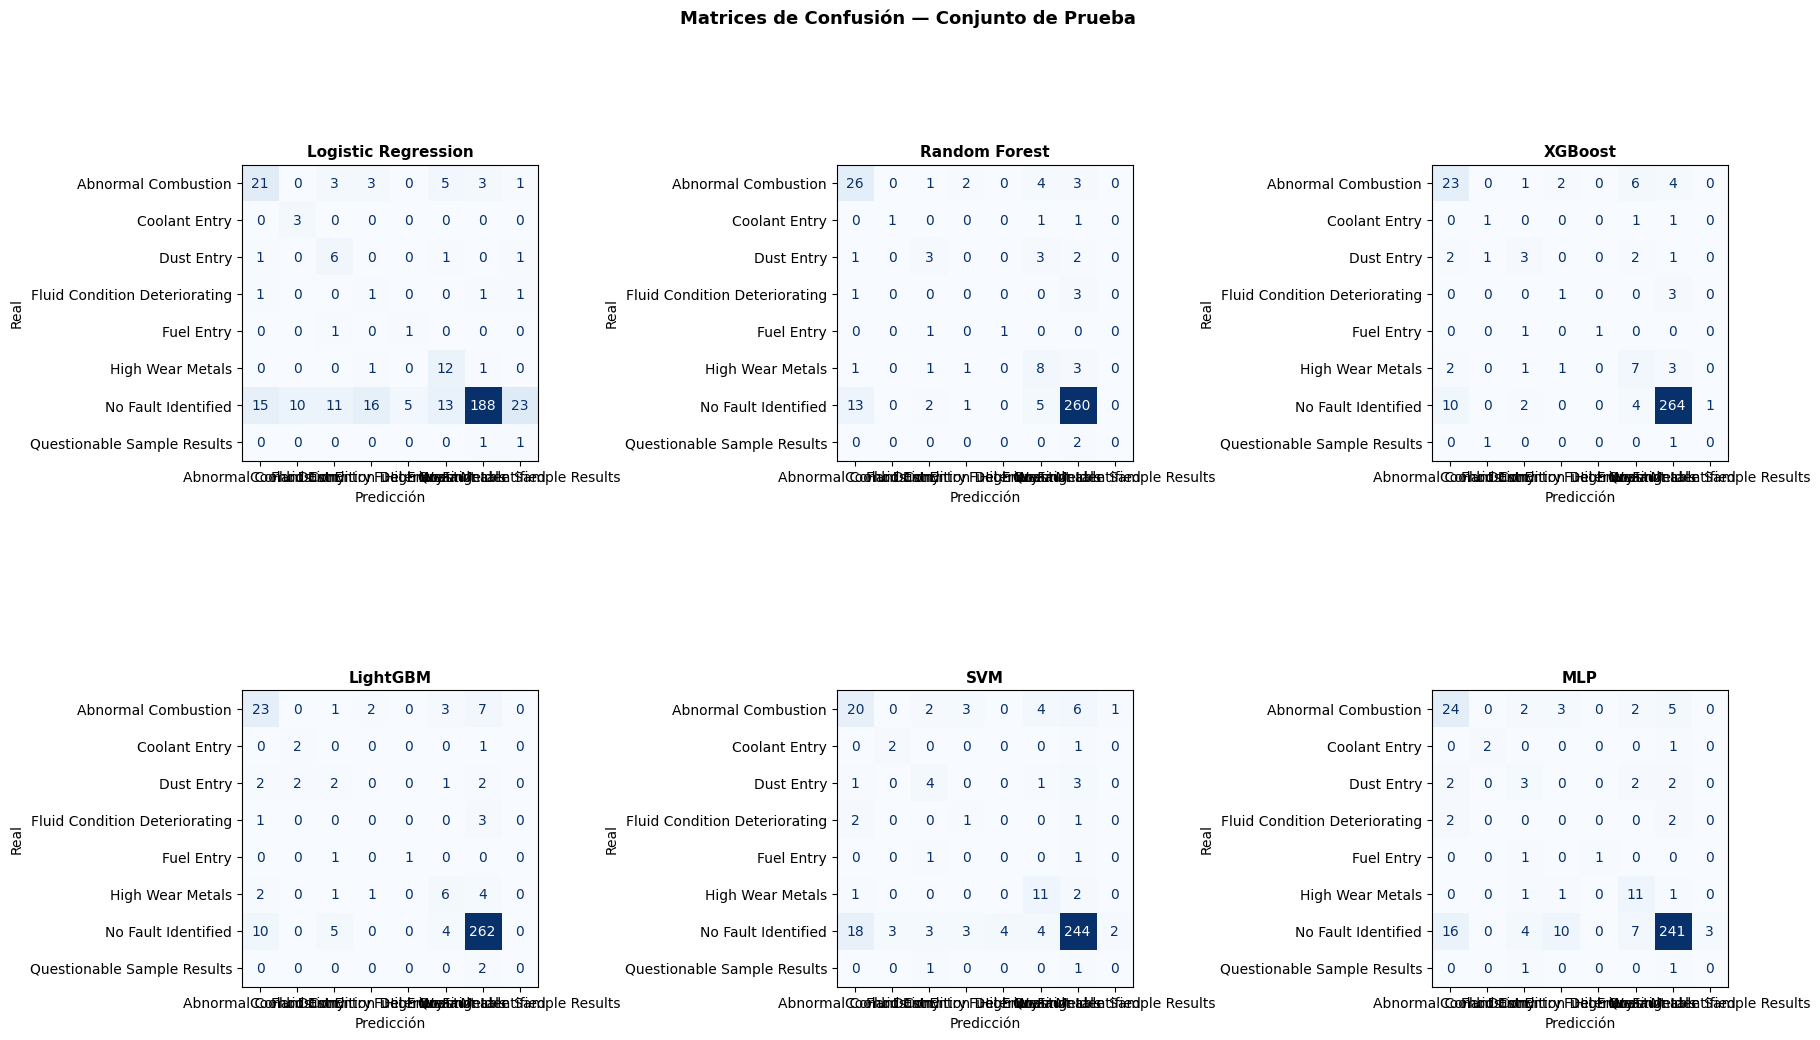

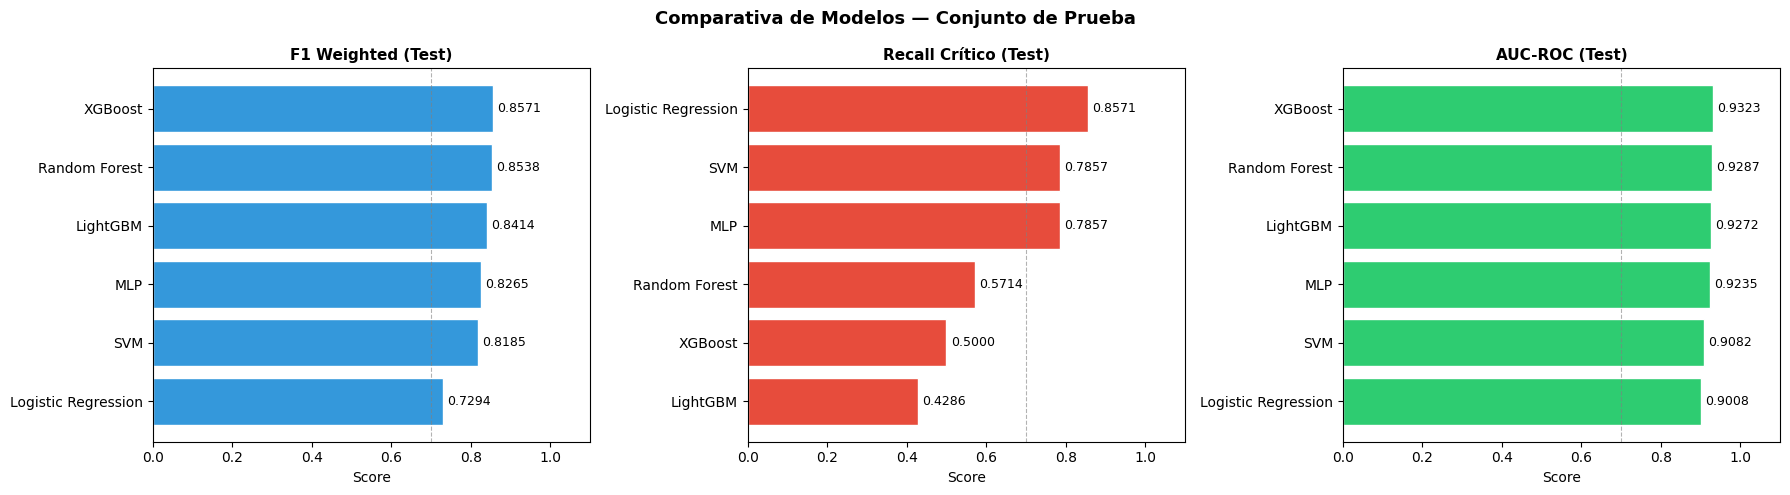

In [111]:
# ==============================================================================
# PIPELINE DE ENTRENAMIENTO — OilSense ML (VERSIÓN FINAL SIN SMOTE)
# ==============================================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.svm              import SVC
from sklearn.neural_network   import MLPClassifier
from sklearn.preprocessing    import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline         import Pipeline
from sklearn.compose          import ColumnTransformer
from sklearn.model_selection  import StratifiedKFold, cross_validate
from sklearn.metrics          import (classification_report,
                                      confusion_matrix,
                                      ConfusionMatrixDisplay,
                                      f1_score, recall_score,
                                      roc_auc_score)

from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier

os.environ['LOKY_MAX_CPU_COUNT'] = '4'
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. COLUMNAS
# ==============================================================================

COLS_DROP = ['Unnamed: 0']

COLS_NUMERICAS = [
    'Boro (ppm)', 'Calcio (ppm)', 'Cinc (ppm)', 'Fosforado (ppm)',
    'Magnesio (ppm)', 'Molibdeno (ppm)', 'Agua (%)',
    'Dilución por combustible (%)', 'Hollín JOAP (Abs/cm)',
    'Nitración JOAP (Abs/cm)', 'Oxidación JOAP (Abs/cm)',
    'Silicio (ppm)', 'Sodio (ppm)', 'Sulfatación JOAP (Abs/cm)',
    'Viscosidad @ 100°C (cSt)', 'Aluminio (ppm)', 'Cobre (ppm)',
    'Cromo (ppm)', 'Estaño (ppm)', 'Hierro (ppm)', 'Plomo (ppm)'
]

COLS_SACODE = [
    'SACODE_Salud',
    'SACODE_Desgaste',
    'SACODE_Contaminacion',
    'SACODE_General'
]

ORDEN_SEVERIDAD = [['Normal', 'Advertencia', 'Crítico']] * len(COLS_SACODE)

# ==============================================================================
# 2. LIMPIEZA DE FEATURES
# ==============================================================================

X_train_bal_clean = X_train_bal.drop(columns=[c for c in COLS_DROP if c in X_train_bal.columns])
X_test_clean      = X_test.drop(columns=[c for c in COLS_DROP if c in X_test.columns])

# ==============================================================================
# 3. LABEL ENCODER (CONSISTENTE)
# ==============================================================================

label_encoder = LabelEncoder()

all_labels = pd.concat([y_train_bal, y_test]).unique()
label_encoder.fit(all_labels)

y_train_enc = label_encoder.transform(y_train_bal)
y_test_enc  = label_encoder.transform(y_test)

CLASES   = label_encoder.classes_
N_CLASES = len(CLASES)

# ==============================================================================
# 4. PREPROCESADORES
# ==============================================================================

preprocessor_scaled = ColumnTransformer([
    ('num', StandardScaler(), COLS_NUMERICAS),
    ('cat', OrdinalEncoder(
        categories=ORDEN_SEVERIDAD,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ), COLS_SACODE)
])

preprocessor_passthrough = ColumnTransformer([
    ('num', 'passthrough', COLS_NUMERICAS),
    ('cat', OrdinalEncoder(
        categories=ORDEN_SEVERIDAD,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ), COLS_SACODE)
])

# ==============================================================================
# 5. MODELOS
# ==============================================================================

modelos = {

    'Logistic Regression': Pipeline([
        ('prep', preprocessor_scaled),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]),

    'Random Forest': Pipeline([
        ('prep', preprocessor_passthrough),
        ('clf', RandomForestClassifier(
            n_estimators=400,
            max_depth=20,
            class_weight='balanced',
            n_jobs=-1,
            random_state=42
        ))
    ]),

    'XGBoost': Pipeline([
        ('prep', preprocessor_passthrough),
        ('clf', XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='multi:softprob',
            num_class=N_CLASES,
            eval_metric='mlogloss',
            n_jobs=-1,
            random_state=42
        ))
    ]),

    'LightGBM': Pipeline([
        ('prep', preprocessor_passthrough),
        ('clf', LGBMClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            class_weight='balanced',
            n_jobs=-1,
            random_state=42,
            verbose=-1
        ))
    ]),

    'SVM': Pipeline([
        ('prep', preprocessor_scaled),
        ('clf', SVC(
            kernel='rbf',
            C=10,
            class_weight='balanced',
            probability=True
        ))
    ]),

    'MLP': Pipeline([
        ('prep', preprocessor_scaled),
        ('clf', MLPClassifier(
            hidden_layer_sizes=(128, 64),
            max_iter=500,
            early_stopping=True,
            random_state=42
        ))
    ])
}

# ==============================================================================
# 5. VALIDACIÓN CRUZADA — 5-Fold Estratificado
# ==============================================================================

print("=" * 65)
print("VALIDACIÓN CRUZADA — 5-Fold Estratificado (Train Balanceado)")
print("=" * 65)

CV           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
METRICAS_CV  = ['f1_weighted', 'recall_weighted', 'accuracy']
resultados_cv = {}

for nombre, pipeline in modelos.items():
    print(f"\n  ▶ Entrenando CV: {nombre}...")
    cv_result = cross_validate(
        estimator          = pipeline,
        X                  = X_train_bal_clean,
        y                  = y_train_enc,
        cv                 = CV,
        scoring            = METRICAS_CV,
        n_jobs             = -1,
        return_train_score = False,
        error_score        = 'raise'
    )
    resultados_cv[nombre] = {
        'F1 Weighted (CV)'    : cv_result['test_f1_weighted'].mean(),
        'F1 Weighted Std'     : cv_result['test_f1_weighted'].std(),
        'Recall Weighted (CV)': cv_result['test_recall_weighted'].mean(),
        'Accuracy (CV)'       : cv_result['test_accuracy'].mean(),
    }
    print(f"    F1 Weighted : {resultados_cv[nombre]['F1 Weighted (CV)']:.4f} "
          f"(±{resultados_cv[nombre]['F1 Weighted Std']:.4f})")
    print(f"    Recall      : {resultados_cv[nombre]['Recall Weighted (CV)']:.4f}")
    print(f"    Accuracy    : {resultados_cv[nombre]['Accuracy (CV)']:.4f}")

df_cv = (pd.DataFrame(resultados_cv).T
           .sort_values('F1 Weighted (CV)', ascending=False))
print("\n=== Resumen Validación Cruzada ===")
print(df_cv.round(4))

# ==============================================================================
# 6. ENTRENAMIENTO FINAL Y EVALUACIÓN SOBRE TEST
# ==============================================================================

print("\n" + "=" * 65)
print("EVALUACIÓN SOBRE CONJUNTO DE PRUEBA (Distribución Original)")
print("=" * 65)

resultados_test = {}
modelos_fit     = {}



CLASE_CRITICA = 'High Wear Metals'  
IDX_CRITICO = np.where(label_encoder.classes_ == CLASE_CRITICA)[0][0]

    


for nombre, pipeline in modelos.items():
    print(f"\n{'─' * 50}")
    print(f"  Modelo: {nombre}")
    print(f"{'─' * 50}")

    pipeline.fit(X_train_bal_clean, y_train_enc)
    modelos_fit[nombre] = pipeline

    y_pred       = pipeline.predict(X_test_clean)
    y_pred_proba = (pipeline.predict_proba(X_test_clean)
                    if hasattr(pipeline[-1], 'predict_proba') else None)

    resultados_test[nombre] = {
        'F1 Weighted (Test)'   : f1_score(y_test_enc, y_pred, average='weighted'),
        'F1 Crítico (Test)'    : f1_score(y_test_enc, y_pred,
                                          labels=[IDX_CRITICO], average=None)[0],
        'Recall Crítico (Test)': recall_score(y_test_enc, y_pred,
                                              labels=[IDX_CRITICO], average=None)[0],
        'AUC-ROC (Test)'       : (roc_auc_score(y_test_enc, y_pred_proba,
                                                 multi_class='ovr', average='weighted')
                                  if y_pred_proba is not None else np.nan),
        'Accuracy (Test)'      : (y_pred == y_test_enc).mean()
    }

    print(classification_report(
        y_test_enc, y_pred,
        target_names=label_encoder.classes_
    ))

df_test = (pd.DataFrame(resultados_test).T
             .sort_values('Recall Crítico (Test)', ascending=False))

print("\n=== Resumen Evaluación Test ===")
print(df_test.round(4))

# ==============================================================================
# 7. MATRICES DE CONFUSIÓN
# ==============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes      = axes.flatten()

for i, (nombre, pipeline) in enumerate(modelos_fit.items()):
    y_pred = pipeline.predict(X_test_clean)
    cm     = confusion_matrix(y_test_enc, y_pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    ).plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(nombre, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Real')

plt.suptitle('Matrices de Confusión — Conjunto de Prueba',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ==============================================================================
# 8. COMPARATIVA VISUAL DE MÉTRICAS
# ==============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (metrica, color) in zip(axes, {
    'F1 Weighted (Test)'   : '#3498db',
    'Recall Crítico (Test)': '#e74c3c',
    'AUC-ROC (Test)'       : '#2ecc71'
}.items()):
    df_plot = df_test[metrica].sort_values(ascending=True)
    bars    = ax.barh(df_plot.index, df_plot.values, color=color, edgecolor='white')
    ax.set_xlim(0, 1.1)
    ax.set_title(metrica, fontsize=11, fontweight='bold')
    ax.set_xlabel('Score')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.axvline(x=0.7, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

plt.suptitle('Comparativa de Modelos — Conjunto de Prueba',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

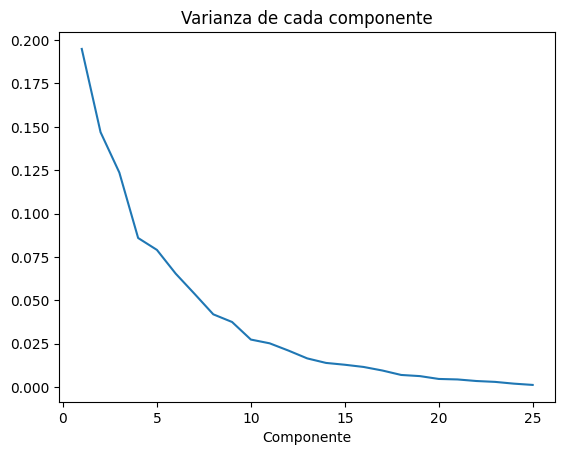

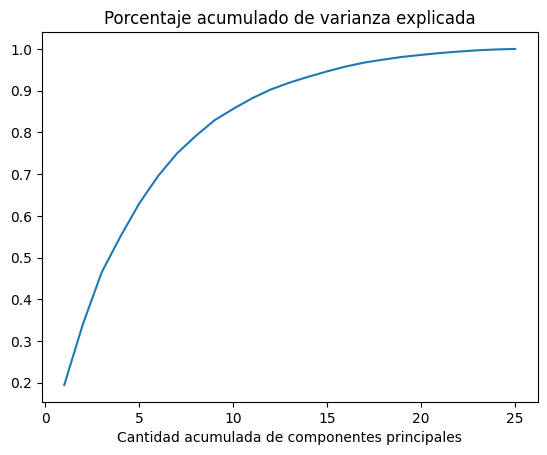

In [112]:
ZTrain,e,loads,eigenvalues,A = PCAR(X_train_bal_clean)

In [135]:
log_reg = LogisticRegression(random_state=42,penalty='l2',max_iter=1000,class_weight='balanced')


# se genera croos validation con 5 folds
cv_result_log=cross_validate(log_reg, ZTrain[:, 0:20], y_train_enc, cv=CV, scoring=METRICAS_CV, n_jobs=-1)

In [136]:
cv_result_log

{'fit_time': array([0.16025162, 0.16416383, 0.17658114, 0.15914488, 0.11280704]),
 'score_time': array([0.00270152, 0.00382948, 0.00229096, 0.00259161, 0.00234151]),
 'test_f1_weighted': array([0.85121789, 0.84860555, 0.84476585, 0.83252232, 0.8449847 ]),
 'test_recall_weighted': array([0.85364496, 0.85141903, 0.84752365, 0.83583751, 0.84743875]),
 'test_accuracy': array([0.85364496, 0.85141903, 0.84752365, 0.83583751, 0.84743875])}

In [139]:
resultados_cv['Logistic Regression PCA'] = {
    'F1 Weighted (CV)'    : cv_result_log['test_f1_weighted'].mean(),
    'F1 Weighted Std'     : cv_result_log['test_f1_weighted'].std(),
    'Recall Weighted (CV)': cv_result_log['test_recall_weighted'].mean(),
    'Accuracy (CV)'       : cv_result_log['test_accuracy'].mean()
}

df_cv = pd.DataFrame(resultados_cv).T.sort_values('F1 Weighted (CV)', ascending=False)
print(df_cv.round(4))

                         F1 Weighted (CV)  F1 Weighted Std  \
LightGBM                           0.9859           0.0024   
XGBoost                            0.9838           0.0028   
Random Forest                      0.9831           0.0028   
MLP                                0.9801           0.0029   
SVM                                0.9788           0.0021   
Logistic Regression                0.8646           0.0091   
Logistic Regression PCA            0.8444           0.0064   

                         Recall Weighted (CV)  Accuracy (CV)  
LightGBM                               0.9861         0.9861  
XGBoost                                0.9840         0.9840  
Random Forest                          0.9833         0.9833  
MLP                                    0.9804         0.9804  
SVM                                    0.9794         0.9794  
Logistic Regression                    0.8673         0.8673  
Logistic Regression PCA                0.8472         0.8472  

### Modelo Flota 2

In [145]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

df_flota2=data_cleaned[data_cleaned['Flota']=='Flota_2']
# Variables predictoras y variable objetivo
X = df_flota2.drop(columns=['Assigned Condition Rating',
                             'ACR_Homologado',
                             'Assigned Condition Rating',
                             'Fault Effect',
                                'SACODE_Salud',
                                'SACODE_Desgaste',
                                'SACODE_Contaminacion',
                                'SACODE_General','Flota','Rule Based Rating'])

y = df_flota2['Fault Effect']


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y       
)

print("=== Distribución antes de SMOTE (Train) ===")
print(y_train.value_counts())

# Aplicación de SMOTE exclusivamente sobre el conjunto de entrenamiento
smote = SMOTE(k_neighbors=4, random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\n=== Distribución después de SMOTE (Train) ===")
print(pd.Series(y_train_bal).value_counts())
print("\n=== Conjunto de prueba (sin modificar) ===")
print(y_test.value_counts())

=== Distribución antes de SMOTE (Train) ===
Fault Effect
No Fault Identified              1095
High Wear Metals                   26
Dust Entry                         25
Fluid Condition Deteriorating      22
Coolant Entry                      16
Abnormal Combustion                11
Fuel Entry                          6
Questionable Sample Results         5
Name: count, dtype: int64

=== Distribución después de SMOTE (Train) ===
Fault Effect
No Fault Identified              1095
Dust Entry                       1095
High Wear Metals                 1095
Fluid Condition Deteriorating    1095
Abnormal Combustion              1095
Questionable Sample Results      1095
Coolant Entry                    1095
Fuel Entry                       1095
Name: count, dtype: int64

=== Conjunto de prueba (sin modificar) ===
Fault Effect
No Fault Identified              274
High Wear Metals                   6
Dust Entry                         6
Fluid Condition Deteriorating      6
Coolant Entry     

In [146]:
Salud_train = X_train_bal[['Boro (ppm)', 'Calcio (ppm)', 'Cinc (ppm)', 'Fosforado (ppm)',
                       'Magnesio (ppm)', 'Molibdeno (ppm)', 'Nitración JOAP (Abs/cm)',
                       'Oxidación JOAP (Abs/cm)', 'Sulfatación JOAP (Abs/cm)', 'Sodio (ppm)']]
Desgaste_train = X_train_bal[['Aluminio (ppm)', 'Cobre (ppm)', 'Cromo (ppm)', 'Estaño (ppm)',
                          'Hierro (ppm)', 'Plomo (ppm)',
                          'Oxidación JOAP (Abs/cm)']]
Contaminacion_train = X_train_bal[['Agua (%)', 'Dilución por combustible (%)',
                               'Hollín JOAP (Abs/cm)', 'Silicio (ppm)',
                               'Sodio (ppm)', 'Aluminio (ppm)']]
X_train_bal['SACODE_Salud']         = calificar_categoria(Salud_train,         limites_flota['Flota_2']['salud'])
X_train_bal['SACODE_Desgaste']      = calificar_categoria(Desgaste_train,      limites_flota['Flota_2']['desgaste'])
X_train_bal['SACODE_Contaminacion'] = calificar_categoria(Contaminacion_train, limites_flota['Flota_2']['contaminacion'])
X_train_bal['SACODE_General'] = X_train_bal[['SACODE_Salud', 'SACODE_Desgaste', 'SACODE_Contaminacion']].apply(
    lambda x: 'Crítico' if 'Crítico' in x.values else ('Advertencia' if 'Advertencia' in x.values else 'Normal'),
    axis=1
)

In [147]:
Salud_test = X_test[['Boro (ppm)', 'Calcio (ppm)', 'Cinc (ppm)', 'Fosforado (ppm)',
                       'Magnesio (ppm)', 'Molibdeno (ppm)', 'Nitración JOAP (Abs/cm)',
                       'Oxidación JOAP (Abs/cm)', 'Sulfatación JOAP (Abs/cm)', 'Sodio (ppm)']]
Desgaste_test = X_test[['Aluminio (ppm)', 'Cobre (ppm)', 'Cromo (ppm)', 'Estaño (ppm)',
                          'Hierro (ppm)', 'Plomo (ppm)',
                          'Oxidación JOAP (Abs/cm)']]
Contaminacion_test = X_test[['Agua (%)', 'Dilución por combustible (%)',
                               'Hollín JOAP (Abs/cm)', 'Silicio (ppm)',
                               'Sodio (ppm)', 'Aluminio (ppm)']]
X_test['SACODE_Salud']         = calificar_categoria(Salud_test,         limites_flota['Flota_2']['salud'])
X_test['SACODE_Desgaste']      = calificar_categoria(Desgaste_test,      limites_flota['Flota_2']['desgaste'])
X_test['SACODE_Contaminacion'] = calificar_categoria(Contaminacion_test, limites_flota['Flota_2']['contaminacion'])
X_test['SACODE_General'] = X_test[['SACODE_Salud', 'SACODE_Desgaste', 'SACODE_Contaminacion']].apply(
    lambda x: 'Crítico' if 'Crítico' in x.values else ('Advertencia' if 'Advertencia' in x.values else 'Normal'),
    axis=1
)

VALIDACIÓN CRUZADA — 5-Fold Estratificado (Train Balanceado)

  ▶ Entrenando CV: Logistic Regression...
    F1 Weighted : 0.9485 (±0.0042)
    Recall      : 0.9501
    Accuracy    : 0.9501

  ▶ Entrenando CV: Random Forest...
    F1 Weighted : 0.9950 (±0.0034)
    Recall      : 0.9951
    Accuracy    : 0.9951

  ▶ Entrenando CV: XGBoost...
    F1 Weighted : 0.9946 (±0.0045)
    Recall      : 0.9946
    Accuracy    : 0.9946

  ▶ Entrenando CV: LightGBM...
    F1 Weighted : 0.9940 (±0.0038)
    Recall      : 0.9941
    Accuracy    : 0.9941

  ▶ Entrenando CV: SVM...
    F1 Weighted : 0.9894 (±0.0014)
    Recall      : 0.9896
    Accuracy    : 0.9896

  ▶ Entrenando CV: MLP...
    F1 Weighted : 0.9887 (±0.0019)
    Recall      : 0.9889
    Accuracy    : 0.9889

=== Resumen Validación Cruzada ===
                     F1 Weighted (CV)  F1 Weighted Std  Recall Weighted (CV)  \
Random Forest                  0.9950           0.0034                0.9951   
XGBoost                        0.994

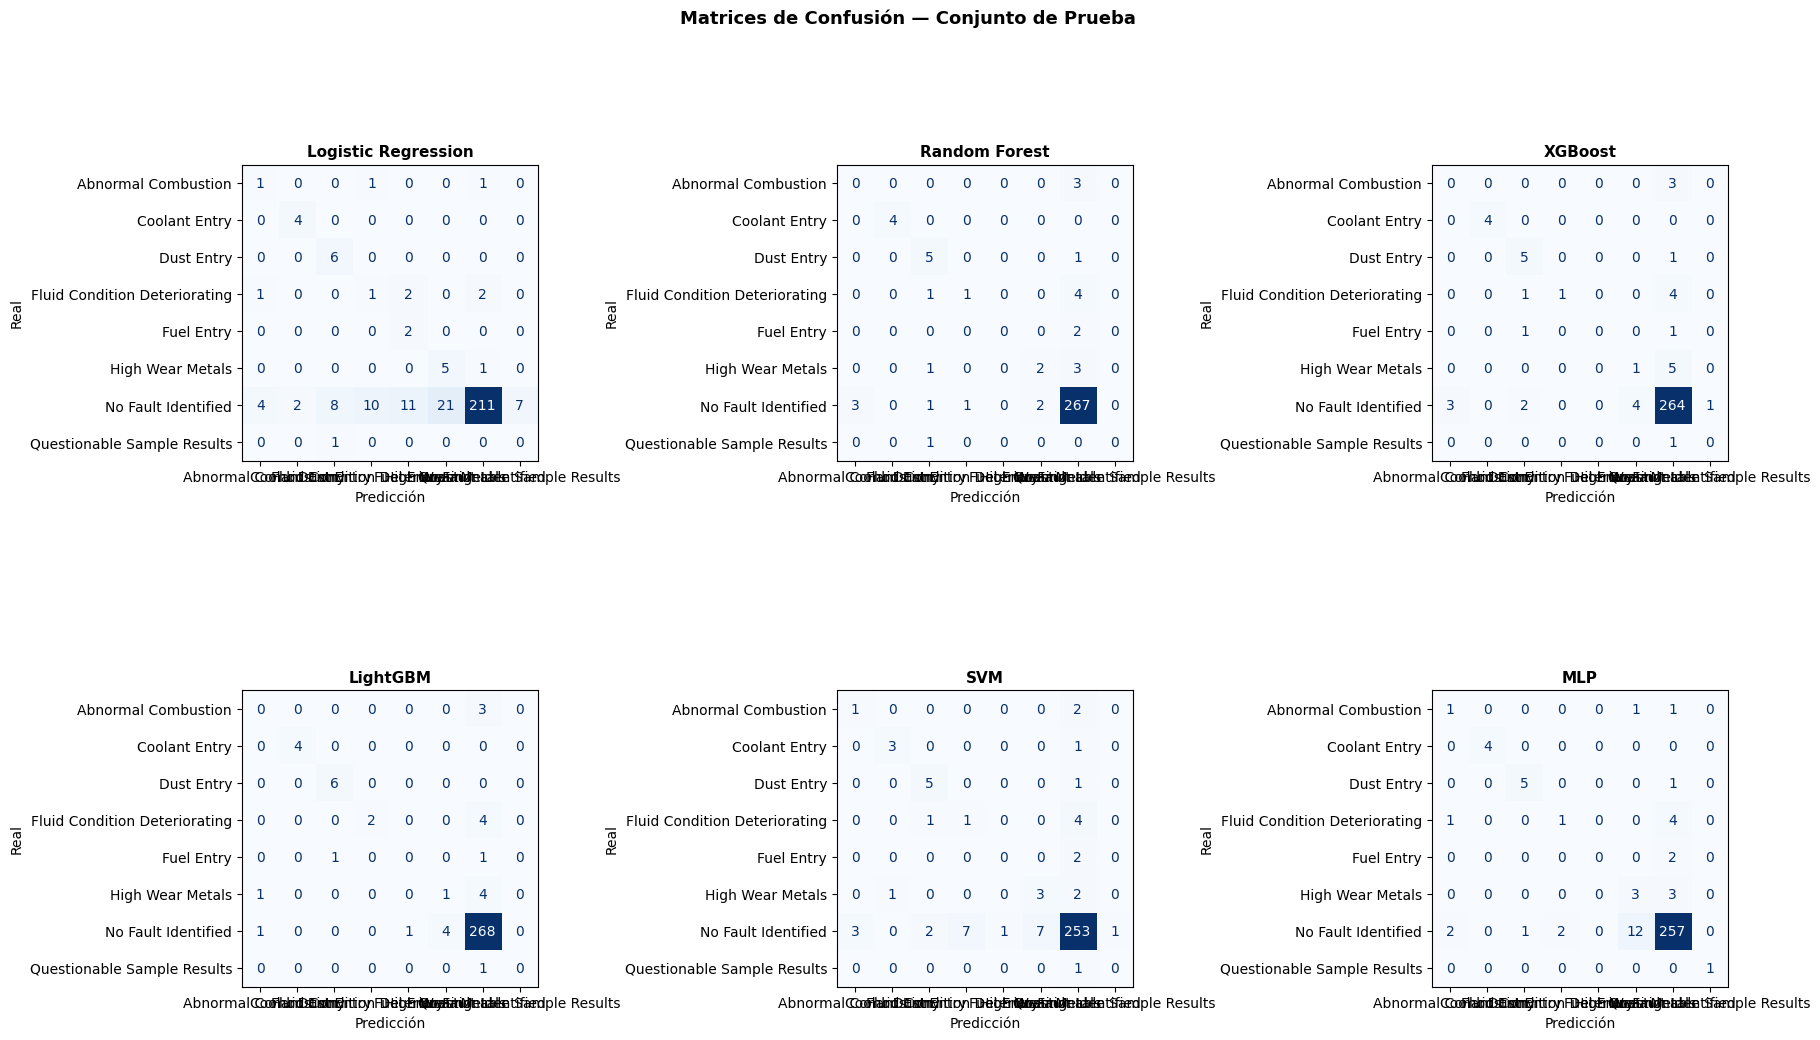

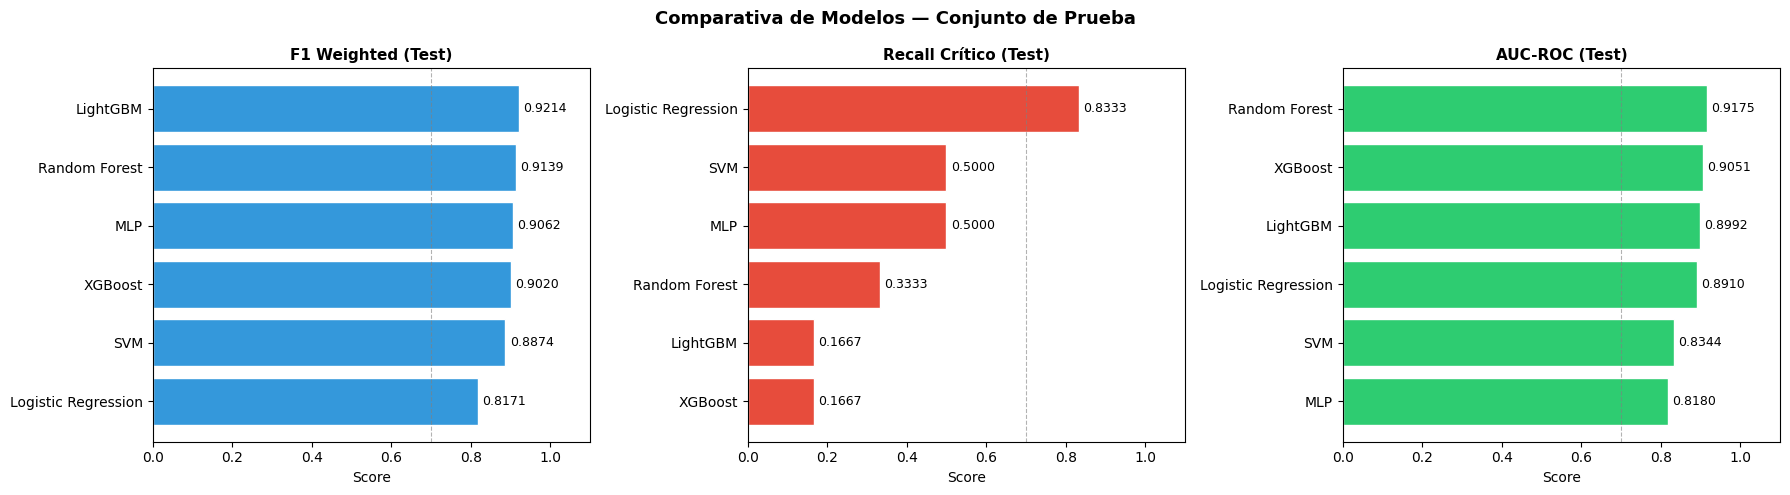

In [148]:

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.svm              import SVC
from sklearn.neural_network   import MLPClassifier
from sklearn.preprocessing    import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline         import Pipeline
from sklearn.compose          import ColumnTransformer
from sklearn.model_selection  import StratifiedKFold, cross_validate
from sklearn.metrics          import (classification_report,
                                      confusion_matrix,
                                      ConfusionMatrixDisplay,
                                      f1_score, recall_score,
                                      roc_auc_score)

from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier

os.environ['LOKY_MAX_CPU_COUNT'] = '4'
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. COLUMNAS
# ==============================================================================

COLS_DROP = ['Unnamed: 0']

COLS_NUMERICAS = [
    'Boro (ppm)', 'Calcio (ppm)', 'Cinc (ppm)', 'Fosforado (ppm)',
    'Magnesio (ppm)', 'Molibdeno (ppm)', 'Agua (%)',
    'Dilución por combustible (%)', 'Hollín JOAP (Abs/cm)',
    'Nitración JOAP (Abs/cm)', 'Oxidación JOAP (Abs/cm)',
    'Silicio (ppm)', 'Sodio (ppm)', 'Sulfatación JOAP (Abs/cm)',
    'Viscosidad @ 100°C (cSt)', 'Aluminio (ppm)', 'Cobre (ppm)',
    'Cromo (ppm)', 'Estaño (ppm)', 'Hierro (ppm)', 'Plomo (ppm)'
]

COLS_SACODE = [
    'SACODE_Salud',
    'SACODE_Desgaste',
    'SACODE_Contaminacion',
    'SACODE_General'
]

ORDEN_SEVERIDAD = [['Normal', 'Advertencia', 'Crítico']] * len(COLS_SACODE)

# ==============================================================================
# 2. LIMPIEZA DE FEATURES
# ==============================================================================

X_train_bal_clean = X_train_bal.drop(columns=[c for c in COLS_DROP if c in X_train_bal.columns])
X_test_clean      = X_test.drop(columns=[c for c in COLS_DROP if c in X_test.columns])

# ==============================================================================
# 3. LABEL ENCODER (CONSISTENTE)
# ==============================================================================

label_encoder = LabelEncoder()

all_labels = pd.concat([y_train_bal, y_test]).unique()
label_encoder.fit(all_labels)

y_train_enc = label_encoder.transform(y_train_bal)
y_test_enc  = label_encoder.transform(y_test)

CLASES   = label_encoder.classes_
N_CLASES = len(CLASES)

# ==============================================================================
# 4. PREPROCESADORES
# ==============================================================================

preprocessor_scaled = ColumnTransformer([
    ('num', StandardScaler(), COLS_NUMERICAS),
    ('cat', OrdinalEncoder(
        categories=ORDEN_SEVERIDAD,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ), COLS_SACODE)
])

preprocessor_passthrough = ColumnTransformer([
    ('num', 'passthrough', COLS_NUMERICAS),
    ('cat', OrdinalEncoder(
        categories=ORDEN_SEVERIDAD,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ), COLS_SACODE)
])

# ==============================================================================
# 5. MODELOS
# ==============================================================================

modelos = {

    'Logistic Regression': Pipeline([
        ('prep', preprocessor_scaled),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]),

    'Random Forest': Pipeline([
        ('prep', preprocessor_passthrough),
        ('clf', RandomForestClassifier(
            n_estimators=400,
            max_depth=20,
            class_weight='balanced',
            n_jobs=-1,
            random_state=42
        ))
    ]),

    'XGBoost': Pipeline([
        ('prep', preprocessor_passthrough),
        ('clf', XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='multi:softprob',
            num_class=N_CLASES,
            eval_metric='mlogloss',
            n_jobs=-1,
            random_state=42
        ))
    ]),

    'LightGBM': Pipeline([
        ('prep', preprocessor_passthrough),
        ('clf', LGBMClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            class_weight='balanced',
            n_jobs=-1,
            random_state=42,
            verbose=-1
        ))
    ]),

    'SVM': Pipeline([
        ('prep', preprocessor_scaled),
        ('clf', SVC(
            kernel='rbf',
            C=10,
            class_weight='balanced',
            probability=True
        ))
    ]),

    'MLP': Pipeline([
        ('prep', preprocessor_scaled),
        ('clf', MLPClassifier(
            hidden_layer_sizes=(128, 64),
            max_iter=500,
            early_stopping=True,
            random_state=42
        ))
    ])
}

# ==============================================================================
# 5. VALIDACIÓN CRUZADA — 5-Fold Estratificado
# ==============================================================================

print("=" * 65)
print("VALIDACIÓN CRUZADA — 5-Fold Estratificado (Train Balanceado)")
print("=" * 65)

CV           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
METRICAS_CV  = ['f1_weighted', 'recall_weighted', 'accuracy']
resultados_cv = {}

for nombre, pipeline in modelos.items():
    print(f"\n  ▶ Entrenando CV: {nombre}...")
    cv_result = cross_validate(
        estimator          = pipeline,
        X                  = X_train_bal_clean,
        y                  = y_train_enc,
        cv                 = CV,
        scoring            = METRICAS_CV,
        n_jobs             = -1,
        return_train_score = False,
        error_score        = 'raise'
    )
    resultados_cv[nombre] = {
        'F1 Weighted (CV)'    : cv_result['test_f1_weighted'].mean(),
        'F1 Weighted Std'     : cv_result['test_f1_weighted'].std(),
        'Recall Weighted (CV)': cv_result['test_recall_weighted'].mean(),
        'Accuracy (CV)'       : cv_result['test_accuracy'].mean(),
    }
    print(f"    F1 Weighted : {resultados_cv[nombre]['F1 Weighted (CV)']:.4f} "
          f"(±{resultados_cv[nombre]['F1 Weighted Std']:.4f})")
    print(f"    Recall      : {resultados_cv[nombre]['Recall Weighted (CV)']:.4f}")
    print(f"    Accuracy    : {resultados_cv[nombre]['Accuracy (CV)']:.4f}")

df_cv = (pd.DataFrame(resultados_cv).T
           .sort_values('F1 Weighted (CV)', ascending=False))
print("\n=== Resumen Validación Cruzada ===")
print(df_cv.round(4))

# ==============================================================================
# 6. ENTRENAMIENTO FINAL Y EVALUACIÓN SOBRE TEST
# ==============================================================================

print("\n" + "=" * 65)
print("EVALUACIÓN SOBRE CONJUNTO DE PRUEBA (Distribución Original)")
print("=" * 65)

resultados_test = {}
modelos_fit     = {}



CLASE_CRITICA = 'High Wear Metals'  
IDX_CRITICO = np.where(label_encoder.classes_ == CLASE_CRITICA)[0][0]

    


for nombre, pipeline in modelos.items():
    print(f"\n{'─' * 50}")
    print(f"  Modelo: {nombre}")
    print(f"{'─' * 50}")

    pipeline.fit(X_train_bal_clean, y_train_enc)
    modelos_fit[nombre] = pipeline

    y_pred       = pipeline.predict(X_test_clean)
    y_pred_proba = (pipeline.predict_proba(X_test_clean)
                    if hasattr(pipeline[-1], 'predict_proba') else None)

    resultados_test[nombre] = {
        'F1 Weighted (Test)'   : f1_score(y_test_enc, y_pred, average='weighted'),
        'F1 Crítico (Test)'    : f1_score(y_test_enc, y_pred,
                                          labels=[IDX_CRITICO], average=None)[0],
        'Recall Crítico (Test)': recall_score(y_test_enc, y_pred,
                                              labels=[IDX_CRITICO], average=None)[0],
        'AUC-ROC (Test)'       : (roc_auc_score(y_test_enc, y_pred_proba,
                                                 multi_class='ovr', average='weighted')
                                  if y_pred_proba is not None else np.nan),
        'Accuracy (Test)'      : (y_pred == y_test_enc).mean()
    }

    print(classification_report(
        y_test_enc, y_pred,
        target_names=label_encoder.classes_
    ))

df_test = (pd.DataFrame(resultados_test).T
             .sort_values('Recall Crítico (Test)', ascending=False))

print("\n=== Resumen Evaluación Test ===")
print(df_test.round(4))

# ==============================================================================
# 7. MATRICES DE CONFUSIÓN
# ==============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes      = axes.flatten()

for i, (nombre, pipeline) in enumerate(modelos_fit.items()):
    y_pred = pipeline.predict(X_test_clean)
    cm     = confusion_matrix(y_test_enc, y_pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    ).plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(nombre, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Real')

plt.suptitle('Matrices de Confusión — Conjunto de Prueba',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ==============================================================================
# 8. COMPARATIVA VISUAL DE MÉTRICAS
# ==============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (metrica, color) in zip(axes, {
    'F1 Weighted (Test)'   : '#3498db',
    'Recall Crítico (Test)': '#e74c3c',
    'AUC-ROC (Test)'       : '#2ecc71'
}.items()):
    df_plot = df_test[metrica].sort_values(ascending=True)
    bars    = ax.barh(df_plot.index, df_plot.values, color=color, edgecolor='white')
    ax.set_xlim(0, 1.1)
    ax.set_title(metrica, fontsize=11, fontweight='bold')
    ax.set_xlabel('Score')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.axvline(x=0.7, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

plt.suptitle('Comparativa de Modelos — Conjunto de Prueba',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Modelo De Severidad de Condicion

In [152]:
X = data_cleaned.drop(columns=['Assigned Condition Rating',
                                'ACR_Homologado',
                                'Assigned Condition Rating','Rule Based Rating'])

y = data_cleaned['Assigned Condition Rating']


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y       
)

VALIDACIÓN CRUZADA — 5-Fold Estratificado (Train Balanceado)

  ▶ Entrenando CV: Logistic Regression...
    F1 Weighted : 0.7990 (±0.0054)
    Recall      : 0.7691
    Accuracy    : 0.7691

  ▶ Entrenando CV: Random Forest...
    F1 Weighted : 0.8405 (±0.0081)
    Recall      : 0.8675
    Accuracy    : 0.8675

  ▶ Entrenando CV: XGBoost...
    F1 Weighted : 0.8599 (±0.0113)
    Recall      : 0.8739
    Accuracy    : 0.8739

  ▶ Entrenando CV: LightGBM...
    F1 Weighted : 0.8614 (±0.0094)
    Recall      : 0.8593
    Accuracy    : 0.8593

  ▶ Entrenando CV: SVM...
    F1 Weighted : 0.8416 (±0.0077)
    Recall      : 0.8287
    Accuracy    : 0.8287

  ▶ Entrenando CV: MLP...
    F1 Weighted : 0.8496 (±0.0072)
    Recall      : 0.8678
    Accuracy    : 0.8678

=== Resumen Validación Cruzada ===
                     F1 Weighted (CV)  F1 Weighted Std  Recall Weighted (CV)  \
LightGBM                       0.8614           0.0094                0.8593   
XGBoost                        0.859

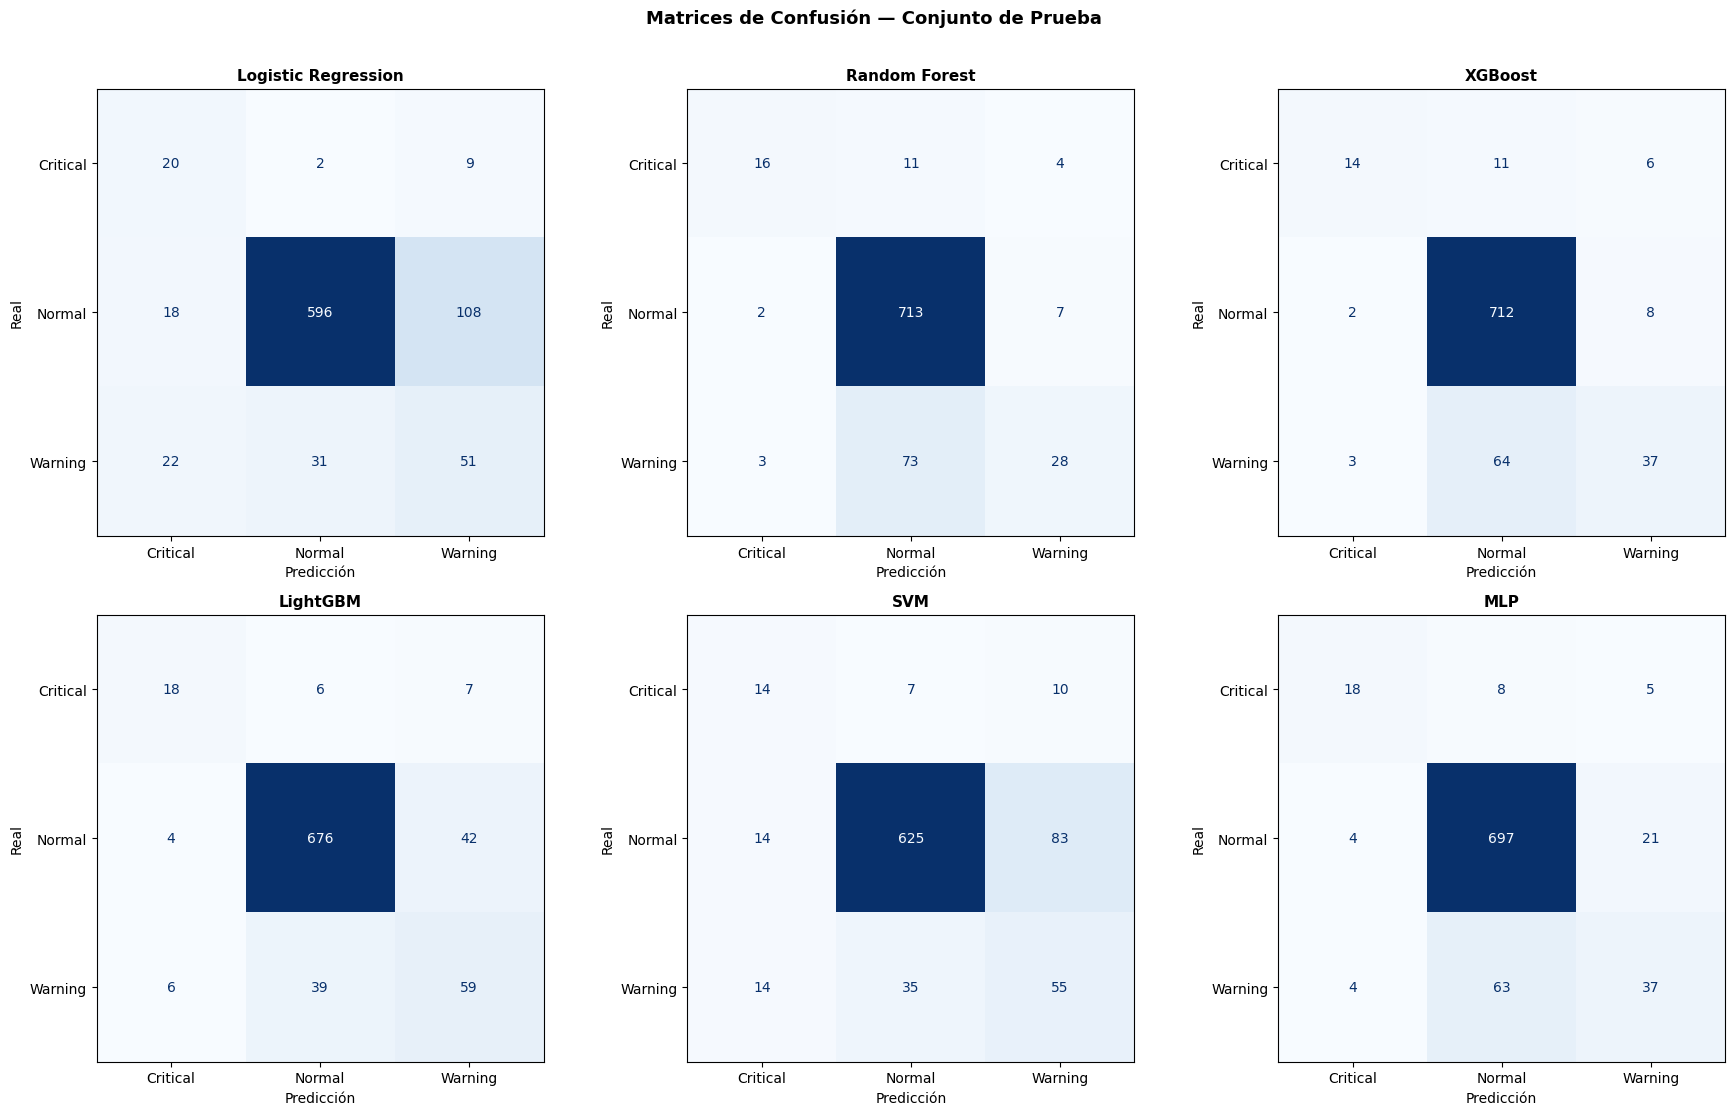

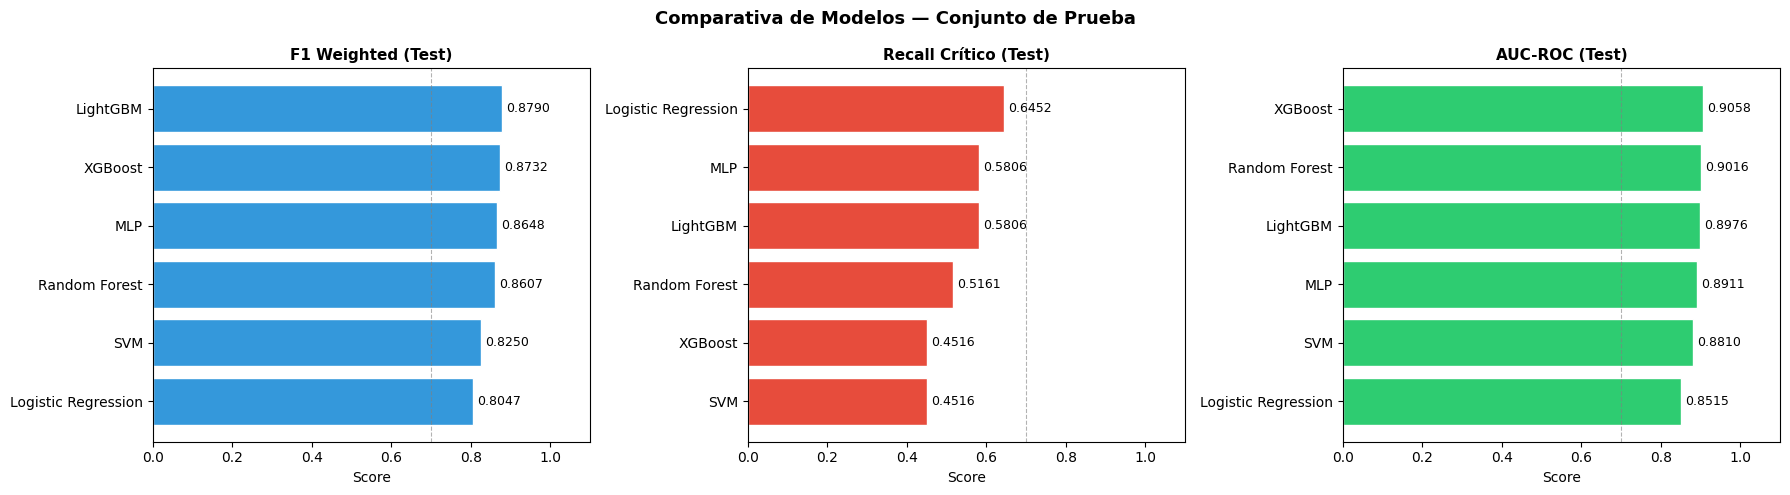

In [157]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.svm              import SVC
from sklearn.neural_network   import MLPClassifier
from sklearn.preprocessing    import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline         import Pipeline
from sklearn.compose          import ColumnTransformer
from sklearn.model_selection  import StratifiedKFold, cross_validate
from sklearn.metrics          import (classification_report,
                                      confusion_matrix,
                                      ConfusionMatrixDisplay,
                                      f1_score, recall_score,
                                      roc_auc_score)

from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier

os.environ['LOKY_MAX_CPU_COUNT'] = '4'
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. COLUMNAS
# ==============================================================================

COLS_DROP = ['Unnamed: 0']

COLS_NUMERICAS = [
    'Boro (ppm)', 'Calcio (ppm)', 'Cinc (ppm)', 'Fosforado (ppm)',
    'Magnesio (ppm)', 'Molibdeno (ppm)', 'Agua (%)',
    'Dilución por combustible (%)', 'Hollín JOAP (Abs/cm)',
    'Nitración JOAP (Abs/cm)', 'Oxidación JOAP (Abs/cm)',
    'Silicio (ppm)', 'Sodio (ppm)', 'Sulfatación JOAP (Abs/cm)',
    'Viscosidad @ 100°C (cSt)', 'Aluminio (ppm)', 'Cobre (ppm)',
    'Cromo (ppm)', 'Estaño (ppm)', 'Hierro (ppm)', 'Plomo (ppm)'
]

COLS_SACODE = [
    'SACODE_Salud',
    'SACODE_Desgaste',
    'SACODE_Contaminacion',
    'SACODE_General',
    'Flota','Fault Effect'
]

ORDEN_SEVERIDAD = [['Normal', 'Advertencia', 'Crítico']] * len(COLS_SACODE)

# ==============================================================================
# 2. LIMPIEZA DE FEATURES
# ==============================================================================

X_train_bal_clean = X_train.drop(columns=[c for c in COLS_DROP if c in X_train.columns])
X_test_clean      = X_test.drop(columns=[c for c in COLS_DROP if c in X_test.columns])

# ==============================================================================
# 3. LABEL ENCODER (CONSISTENTE)
# ==============================================================================

label_encoder = LabelEncoder()

all_labels = pd.concat([y_train, y_test]).unique()
label_encoder.fit(all_labels)

y_train_enc = label_encoder.transform(y_train)
y_test_enc  = label_encoder.transform(y_test)

CLASES   = label_encoder.classes_
N_CLASES = len(CLASES)

# ==============================================================================
# 4. PREPROCESADORES
# ==============================================================================

preprocessor_scaled = ColumnTransformer([
    ('num', StandardScaler(), COLS_NUMERICAS),
    ('cat', OrdinalEncoder(
        categories=ORDEN_SEVERIDAD,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ), COLS_SACODE)
])

preprocessor_passthrough = ColumnTransformer([
    ('num', 'passthrough', COLS_NUMERICAS),
    ('cat', OrdinalEncoder(
        categories=ORDEN_SEVERIDAD,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ), COLS_SACODE)
])

# ==============================================================================
# 5. MODELOS
# ==============================================================================

modelos = {

    'Logistic Regression': Pipeline([
        ('prep', preprocessor_scaled),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]),

    'Random Forest': Pipeline([
        ('prep', preprocessor_passthrough),
        ('clf', RandomForestClassifier(
            n_estimators=400,
            max_depth=20,
            class_weight='balanced',
            n_jobs=-1,
            random_state=42
        ))
    ]),

    'XGBoost': Pipeline([
        ('prep', preprocessor_passthrough),
        ('clf', XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='multi:softprob',
            num_class=N_CLASES,
            eval_metric='mlogloss',
            n_jobs=-1,
            random_state=42
        ))
    ]),

    'LightGBM': Pipeline([
        ('prep', preprocessor_passthrough),
        ('clf', LGBMClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            class_weight='balanced',
            n_jobs=-1,
            random_state=42,
            verbose=-1
        ))
    ]),

    'SVM': Pipeline([
        ('prep', preprocessor_scaled),
        ('clf', SVC(
            kernel='rbf',
            C=10,
            class_weight='balanced',
            probability=True
        ))
    ]),

    'MLP': Pipeline([
        ('prep', preprocessor_scaled),
        ('clf', MLPClassifier(
            hidden_layer_sizes=(128, 64),
            max_iter=500,
            early_stopping=True,
            random_state=42
        ))
    ])
}

# ==============================================================================
# 5. VALIDACIÓN CRUZADA — 5-Fold Estratificado
# ==============================================================================

print("=" * 65)
print("VALIDACIÓN CRUZADA — 5-Fold Estratificado (Train Balanceado)")
print("=" * 65)

CV           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
METRICAS_CV  = ['f1_weighted', 'recall_weighted', 'accuracy']
resultados_cv = {}

for nombre, pipeline in modelos.items():
    print(f"\n  ▶ Entrenando CV: {nombre}...")
    cv_result = cross_validate(
        estimator          = pipeline,
        X                  = X_train_bal_clean,
        y                  = y_train_enc,
        cv                 = CV,
        scoring            = METRICAS_CV,
        n_jobs             = -1,
        return_train_score = False,
        error_score        = 'raise'
    )
    resultados_cv[nombre] = {
        'F1 Weighted (CV)'    : cv_result['test_f1_weighted'].mean(),
        'F1 Weighted Std'     : cv_result['test_f1_weighted'].std(),
        'Recall Weighted (CV)': cv_result['test_recall_weighted'].mean(),
        'Accuracy (CV)'       : cv_result['test_accuracy'].mean(),
    }
    print(f"    F1 Weighted : {resultados_cv[nombre]['F1 Weighted (CV)']:.4f} "
          f"(±{resultados_cv[nombre]['F1 Weighted Std']:.4f})")
    print(f"    Recall      : {resultados_cv[nombre]['Recall Weighted (CV)']:.4f}")
    print(f"    Accuracy    : {resultados_cv[nombre]['Accuracy (CV)']:.4f}")

df_cv = (pd.DataFrame(resultados_cv).T
           .sort_values('F1 Weighted (CV)', ascending=False))
print("\n=== Resumen Validación Cruzada ===")
print(df_cv.round(4))

# ==============================================================================
# 6. ENTRENAMIENTO FINAL Y EVALUACIÓN SOBRE TEST
# ==============================================================================

print("\n" + "=" * 65)
print("EVALUACIÓN SOBRE CONJUNTO DE PRUEBA (Distribución Original)")
print("=" * 65)

resultados_test = {}
modelos_fit     = {}



CLASE_CRITICA = 'Critical'  
IDX_CRITICO = np.where(label_encoder.classes_ == CLASE_CRITICA)[0][0]

    


for nombre, pipeline in modelos.items():
    print(f"\n{'─' * 50}")
    print(f"  Modelo: {nombre}")
    print(f"{'─' * 50}")

    pipeline.fit(X_train_bal_clean, y_train_enc)
    modelos_fit[nombre] = pipeline

    y_pred       = pipeline.predict(X_test_clean)
    y_pred_proba = (pipeline.predict_proba(X_test_clean)
                    if hasattr(pipeline[-1], 'predict_proba') else None)

    resultados_test[nombre] = {
        'F1 Weighted (Test)'   : f1_score(y_test_enc, y_pred, average='weighted'),
        'F1 Crítico (Test)'    : f1_score(y_test_enc, y_pred,
                                          labels=[IDX_CRITICO], average=None)[0],
        'Recall Crítico (Test)': recall_score(y_test_enc, y_pred,
                                              labels=[IDX_CRITICO], average=None)[0],
        'AUC-ROC (Test)'       : (roc_auc_score(y_test_enc, y_pred_proba,
                                                 multi_class='ovr', average='weighted')
                                  if y_pred_proba is not None else np.nan),
        'Accuracy (Test)'      : (y_pred == y_test_enc).mean()
    }

    print(classification_report(
        y_test_enc, y_pred,
        target_names=label_encoder.classes_
    ))

df_test = (pd.DataFrame(resultados_test).T
             .sort_values('Recall Crítico (Test)', ascending=False))

print("\n=== Resumen Evaluación Test ===")
print(df_test.round(4))

# ==============================================================================
# 7. MATRICES DE CONFUSIÓN
# ==============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes      = axes.flatten()

for i, (nombre, pipeline) in enumerate(modelos_fit.items()):
    y_pred = pipeline.predict(X_test_clean)
    cm     = confusion_matrix(y_test_enc, y_pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    ).plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(nombre, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Real')

plt.suptitle('Matrices de Confusión — Conjunto de Prueba',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ==============================================================================
# 8. COMPARATIVA VISUAL DE MÉTRICAS
# ==============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (metrica, color) in zip(axes, {
    'F1 Weighted (Test)'   : '#3498db',
    'Recall Crítico (Test)': '#e74c3c',
    'AUC-ROC (Test)'       : '#2ecc71'
}.items()):
    df_plot = df_test[metrica].sort_values(ascending=True)
    bars    = ax.barh(df_plot.index, df_plot.values, color=color, edgecolor='white')
    ax.set_xlim(0, 1.1)
    ax.set_title(metrica, fontsize=11, fontweight='bold')
    ax.set_xlabel('Score')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.axvline(x=0.7, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

plt.suptitle('Comparativa de Modelos — Conjunto de Prueba',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [170]:
#se cuentan las muestras por severidad en y_train
y_train.value_counts()

Assigned Condition Rating
Normal      2885
Warning      418
Critical     123
Name: count, dtype: int64